# Generation of the input models
@Author: Nyota Buduli Masirika

In [2]:
#packages

import numpy as np
from astropy.io import fits
from astropy import units as u
import os 
from functions import *
from variables import *

In [3]:
#Changement of folder (needed to work with ScopeSim)
os.chdir("ScopeSim") #relative path to ScopeSim folder
print(os.getcwd())

c:\Users\Nyota\OneDrive - Universite de Liege\MASTER 3\TFE_AGN\Code\ScopeSim


## Functions and Variables
General variables linked to METIS, ScopeSim, etc. are in [variables.py](variables.py) and [functions.py](functions.py).

### i. Files
To create the `FITS` file, we must make the header compatible with `ScopeSim`. Let's load the header of an example image used for `ScopeSim` to see the good header format. If you do not have the example file, uncomment the box below to download the file and set the associate variables.

In [4]:
# see variables.py

### ii. Useful Variables

General variables linked to METIS, ScopeSim, etc. are in [variables.py](variables.py) and [functions.py](functions.py).

In [5]:
# see variables.py

### iii. Mean Variance
Function to apply the error propagation formula to retrieve the mean Variance of an array:

$$\sigma_\text{mean}^2 = \frac{1}{N} \sigma_\text{tot}^2 = \frac{1}{N} \sum^N_i \sigma_i^2$$

where $N$ is the number of pixel in the subarray and the variance for a Poisson distribution is
$$\sigma^2 = \lambda * t$$
with $\lambda$ the rate at which the photons arrive and $t$ the integration time.

In [6]:
# see functions.py

## 1. Circinus FITS file
Now that our [database](./outputs/selected_galaxies.csv) is complete, we can prepare our exploitation of `ScopeSim`. First, we will need an input image to feed to `ScopeSim`. To do that we use the case of `Circinus`. As a first approximation, we represent Circinus as a 2D circular Gaussian using its angular size and flux measured by [[1]](https://arxiv.org/abs/1310.2770). We will make an attempt with 2D elliptical Gaussian later. 

### 1.1. Circular Gaussian
We write a function that returns an array containing a 2D circular Gaussian profile following this formula: 
$$
G = I * \exp{\left(-0.5 * \left(\left(\frac{x-x_c}{\sigma}\right)^2 + \left(\frac{y-y_c}{\sigma}\right)^2 \right)\right)}
$$

To create the `FITS` file, we must make the header compatible with `ScopeSim`. Let's load the header of an example image used for `ScopeSim` to see the good header format. We modify the `header` based on our object and save the `FITS` file. The others parameters of the `header` are unchanged for now as they are not useful.

In [7]:
#see function.py

#### 1.1.1. N-band
We can now generate the 2D circular Gaussian for Circinus.

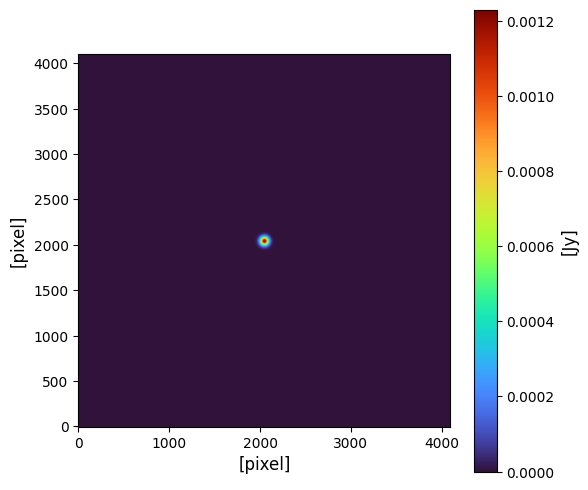

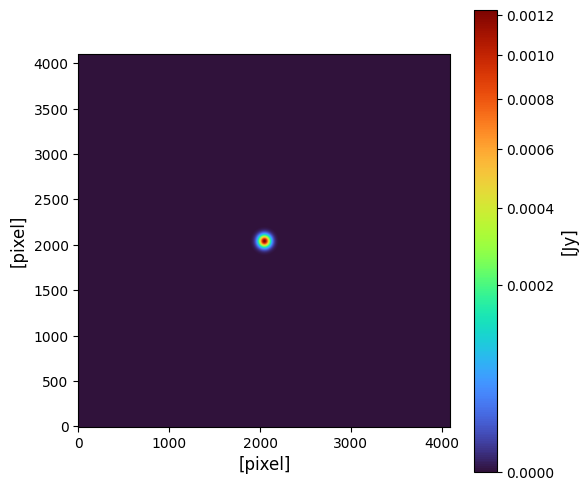

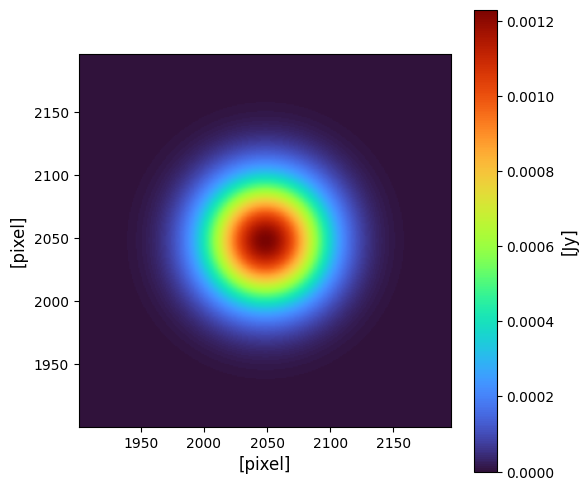

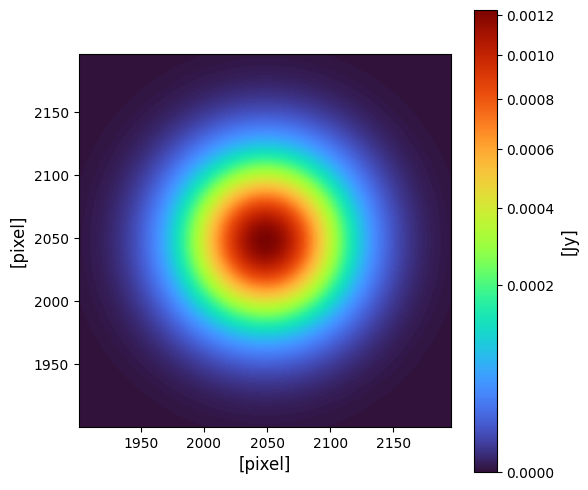

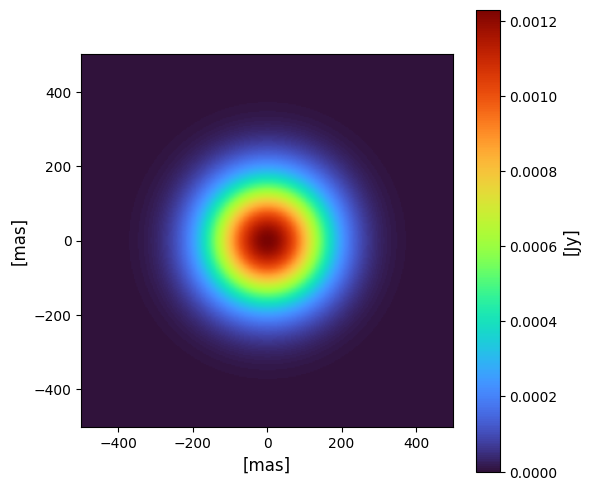

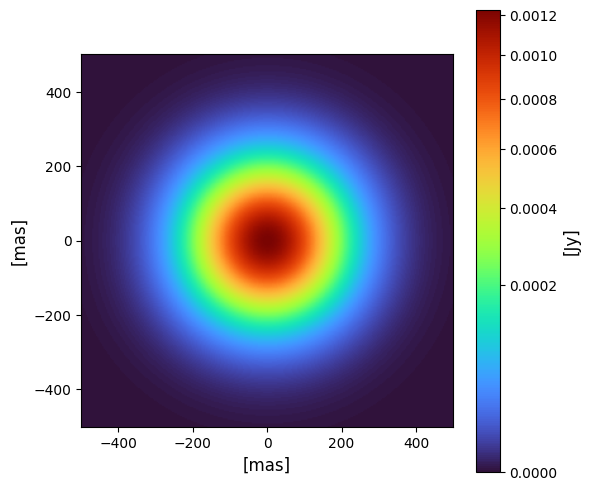

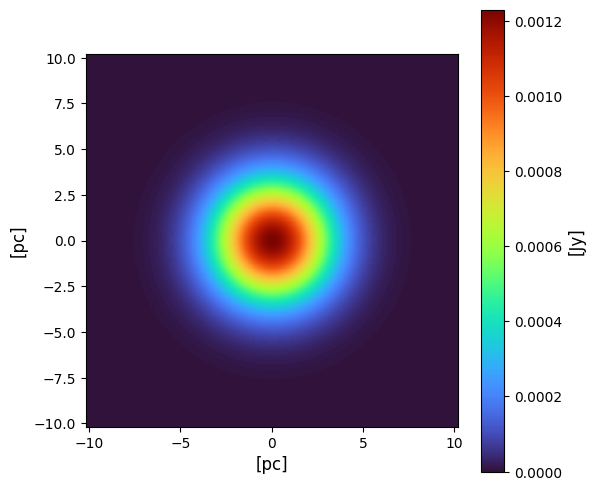

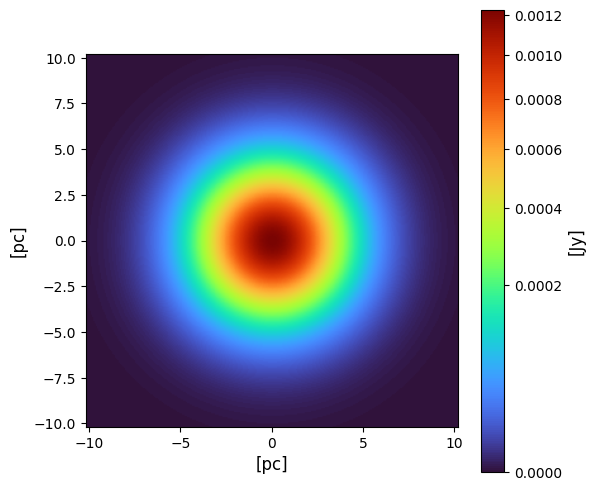

In [8]:
# Generation of the 2D circular Gaussian of Circinus

F_circinus = 8.327 * u.Jy
Angular_size_circinus = 262.25096794270144 *u.mas
FWHM_circinus = 5.34 * u.pc
D_circinus = 4.2 *u.Mpc

Circular_Circinus = Circular_Gaussian_profile(FWHM=FWHM_circinus, flux=F_circinus, pixel_size_mas=METIS_N_band_pixel_scale/2, 
                                              Dist_source=D_circinus, mode='img_n', object_name='Circinus', 
                                              creating_plot_and_FITS=True, window_lim=500*u.mas)


Unresolved point source

### 1.2. Elliptical Gaussian

To approximate elliptical objects.

In [9]:
# see functions.py

#### 1.2.1. L-band
Following the article

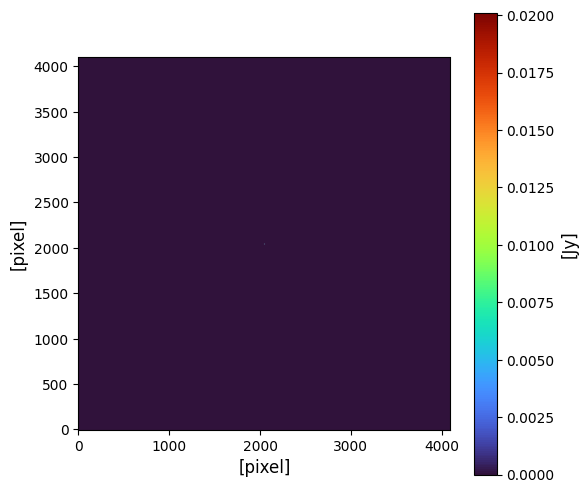

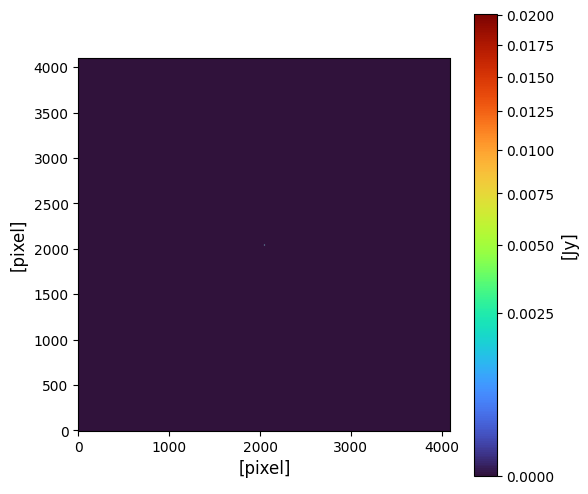

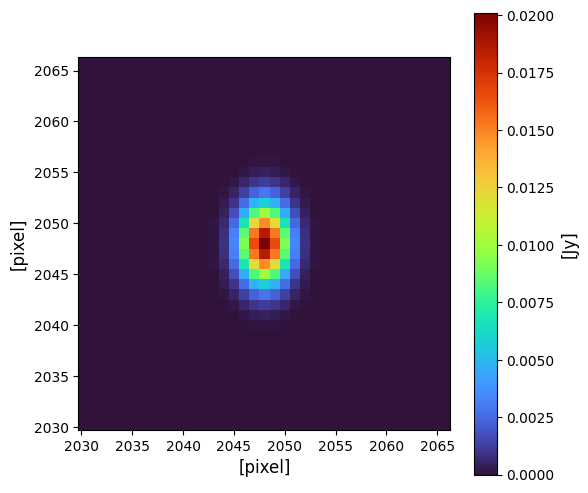

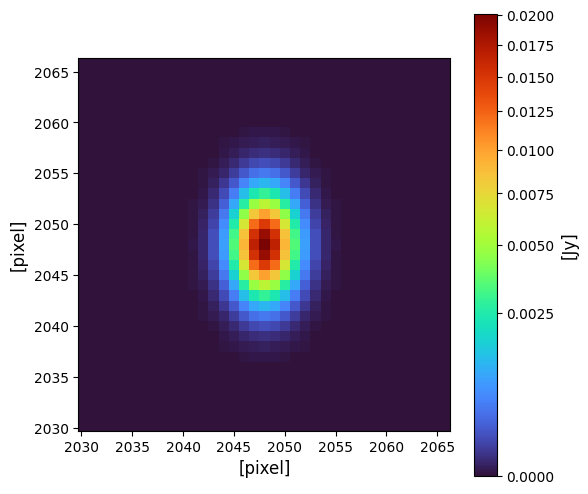

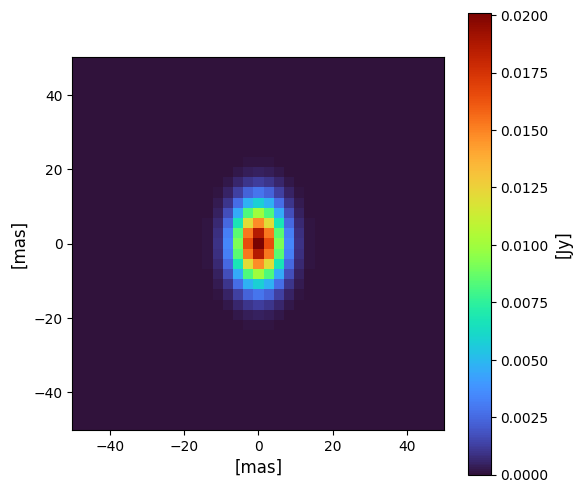

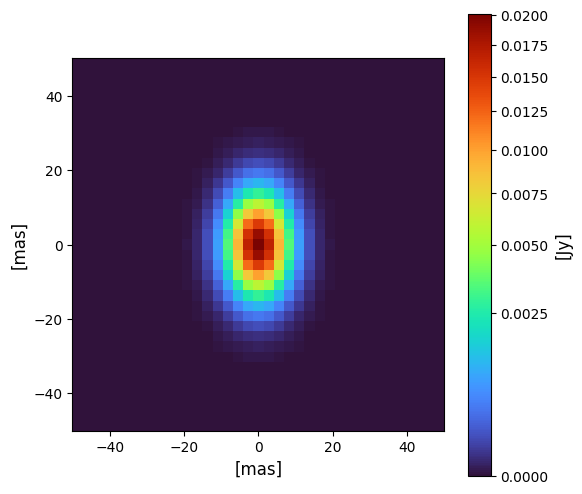

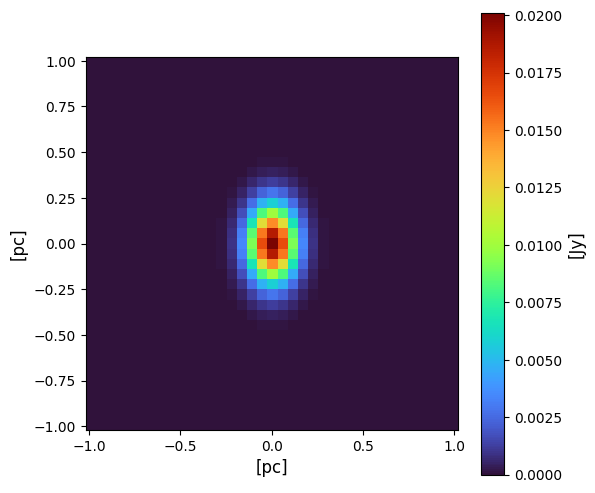

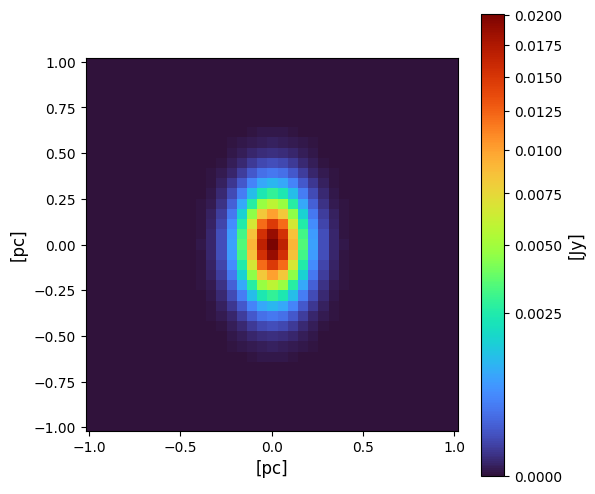

In [10]:
# Generation of the 2D circular Gaussian of Circinus

THETA_L_circinus = 16.3*u.mas 
r_L_circinus = 0.63
flux_L_circinus = 510*u.mJy
FWHM_L_Circinus_x = mas_to_pc(THETA_L_circinus, D_circinus)

Elliptical_Circinus_L = Elliptical_Gaussian_profile(FWHM_x=FWHM_L_Circinus_x, FWHM_y=r_L_circinus*FWHM_L_Circinus_x, theta=0*u.degree, flux=flux_L_circinus, 
                                                    pixel_size_mas=METIS_L_band_pixel_scale/2, Dist_source=D_circinus, mode='img_lm', 
                                                    object_name='Circinus', creating_plot_and_FITS=True, window_lim=50*u.mas)


### 1.3. Pt source with extended emission (2 parts)

We can merge a Circular Gaussian with an Elliptical Gaussian to create a pt source with extended emission

In [11]:
# see functions.py

In [12]:
# Generation of the 2D circular Gaussian of Circinus
FWHM_unres = mas_to_pc(pxl_unres_x*CDELT_circinus_original, D_circinus)
FWHM_disk_x = mas_to_pc(pxl_disk_x*CDELT_circinus_original, D_circinus)
FWHM_disk_y = mas_to_pc(pxl_disk_y*CDELT_circinus_original, D_circinus)
FWHM_polar_x = mas_to_pc(pxl_polar_x*CDELT_circinus_original, D_circinus)
FWHM_polar_y = mas_to_pc(pxl_polar_y*CDELT_circinus_original, D_circinus)

FWHM_unres , FWHM_disk_x, FWHM_disk_y , FWHM_polar_x , FWHM_polar_y 

(<Quantity 0.11930962 pc>,
 <Quantity 1.03401668 pc>,
 <Quantity 0.23861923 pc>,
 <Quantity 2.1475731 pc>,
 <Quantity 0.87493719 pc>)

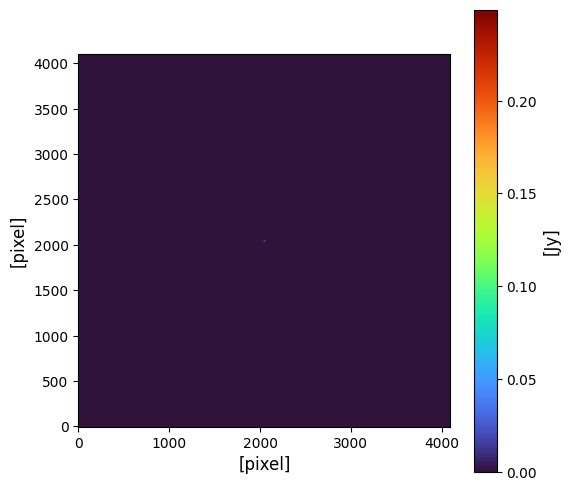

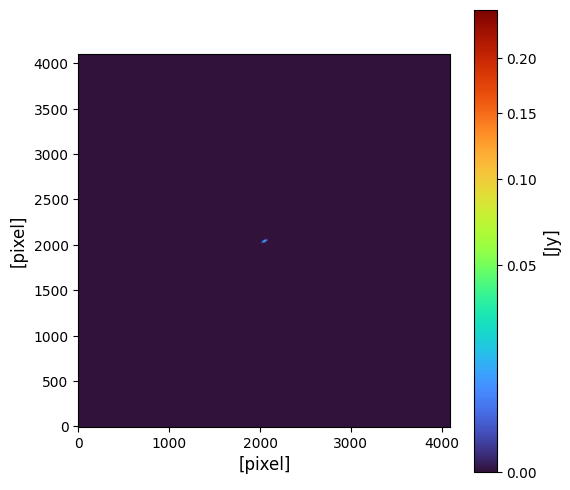

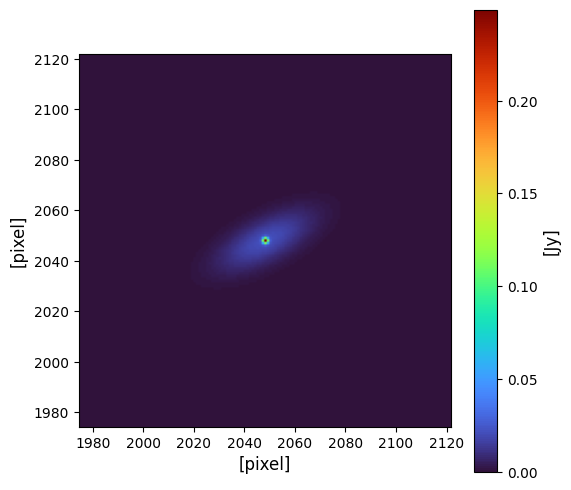

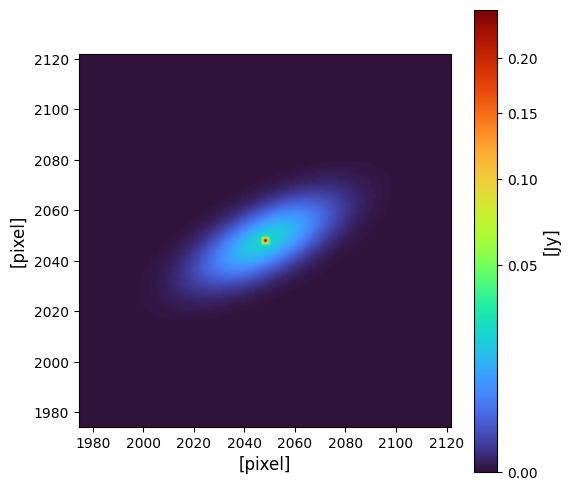

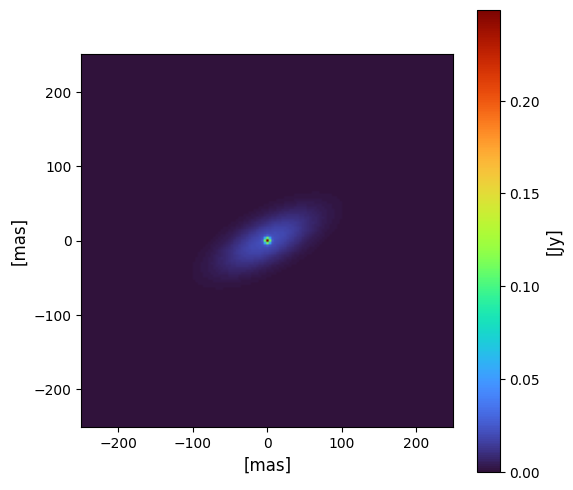

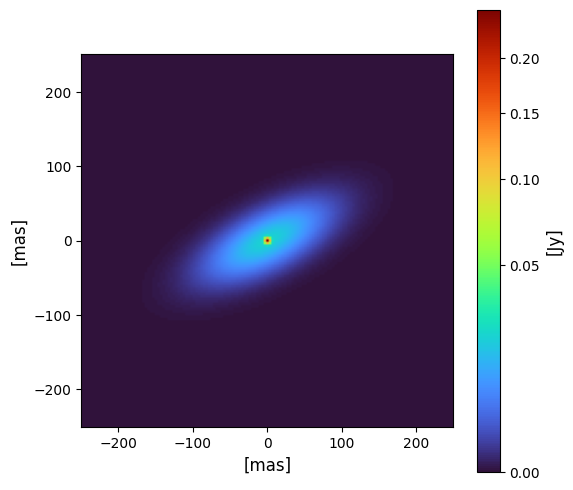

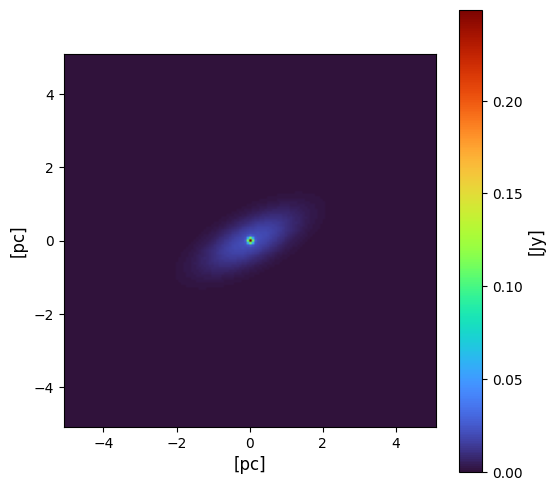

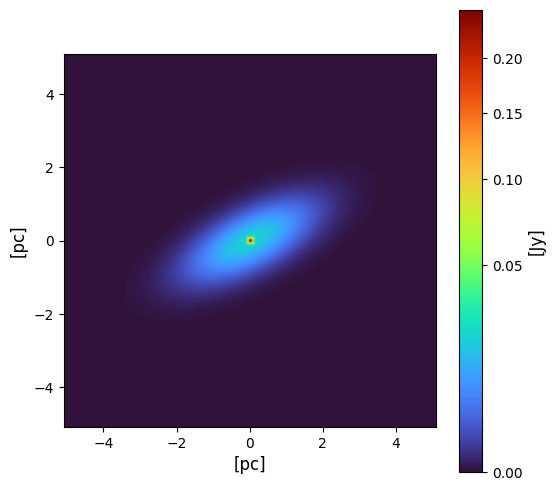

In [13]:
Circinus_1pt_1elliptical = create_model_3compo(FWHM_unres=FWHM_unres, flux_unres=flux_unres,
                                              FWHM_polar_x=FWHM_polar_y, FWHM_polar_y=FWHM_polar_x, flux_polar=flux_polar+flux_disk, theta_polar=theta_polar,
                                              FWHM_disk_x=0*u.pc, FWHM_disk_y=0*u.pc, flux_disk=0*u.Jy, theta_disk=theta_disk,
                                              pixel_size_mas=METIS_N_band_pixel_scale/2, Dist_source=D_circinus, d_offset=0,
                                              mode='img_n', object_name="Circinus_1pt_1elliptical", 
                                              creating_plot_and_FITS=True, window_lim=250*u.mas)


In [14]:
"""G_ellipt_circinus_unres = Elliptical_Gaussian_profile(FWHM_x=FWHM_polar_y, FWHM_y=FWHM_polar_x, theta=27*u.degree, flux=(7.79+1.61)*u.Jy, 
                                              pixel_size=pixel_size_circinus, Dist_source=D_circinus, grid_length_factor=10, 
                                              example_file=example_FITS, band_name="N", source_name="Circinus_extended", creating_plot_and_FITS=True)"""

'G_ellipt_circinus_unres = Elliptical_Gaussian_profile(FWHM_x=FWHM_polar_y, FWHM_y=FWHM_polar_x, theta=27*u.degree, flux=(7.79+1.61)*u.Jy, \n                                              pixel_size=pixel_size_circinus, Dist_source=D_circinus, grid_length_factor=10, \n                                              example_file=example_FITS, band_name="N", source_name="Circinus_extended", creating_plot_and_FITS=True)'

### 1.4. Pt source with extended emission (3 parts)

We can merge a Circular Gaussian with two Elliptical Gaussians to create an unres pt source with extended emissions

In [15]:
# see functions.py

In [16]:
pxl_unres_x*CDELT_circinus_original, pxl_disk_x*CDELT_circinus_original, pxl_disk_y*CDELT_circinus_original, pxl_polar_x*CDELT_circinus_original, pxl_polar_y*CDELT_circinus_original

(<Quantity 5.859375 mas>,
 <Quantity 50.78125 mas>,
 <Quantity 11.71875 mas>,
 <Quantity 105.46875 mas>,
 <Quantity 42.96875 mas>)

In [17]:
FWHM_unres = mas_to_pc(pxl_unres_x*CDELT_circinus_original, D_circinus)
FWHM_disk_x = mas_to_pc(pxl_disk_x*CDELT_circinus_original, D_circinus)
FWHM_disk_y = mas_to_pc(pxl_disk_y*CDELT_circinus_original, D_circinus)
FWHM_polar_x = mas_to_pc(pxl_polar_x*CDELT_circinus_original, D_circinus)
FWHM_polar_y = mas_to_pc(pxl_polar_y*CDELT_circinus_original, D_circinus)

FWHM_unres , FWHM_disk_x, FWHM_disk_y , FWHM_polar_x , FWHM_polar_y 


(<Quantity 0.11930962 pc>,
 <Quantity 1.03401668 pc>,
 <Quantity 0.23861923 pc>,
 <Quantity 2.1475731 pc>,
 <Quantity 0.87493719 pc>)

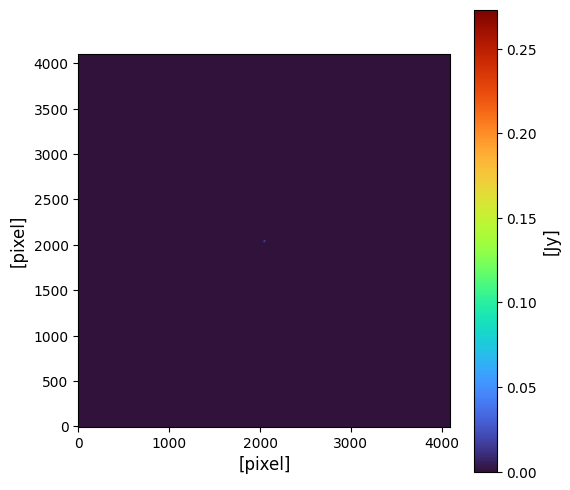

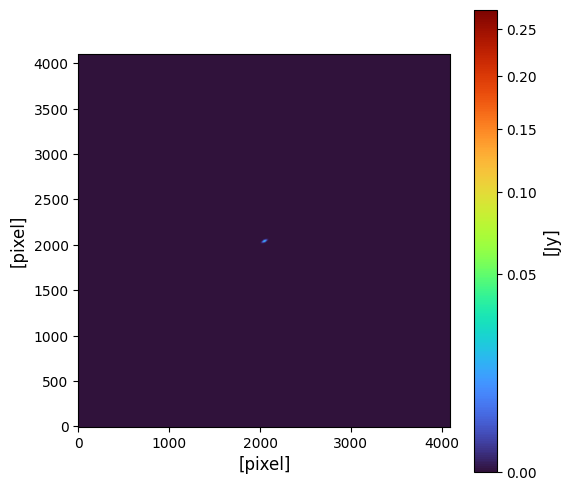

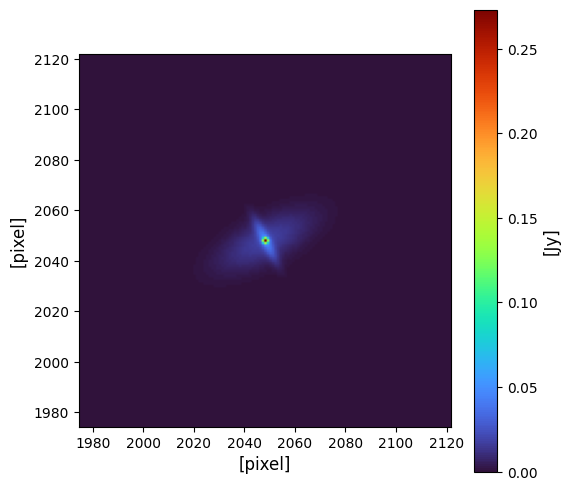

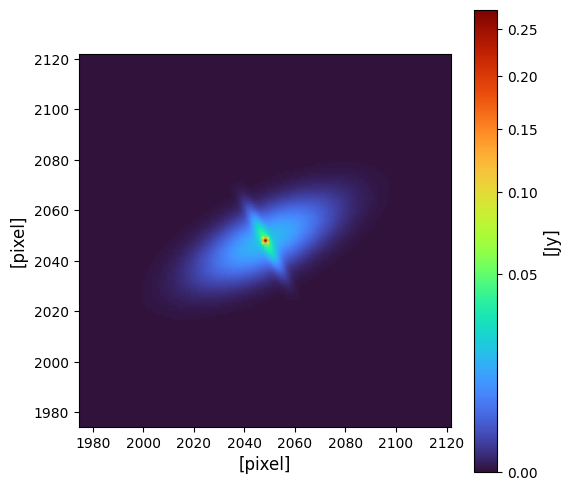

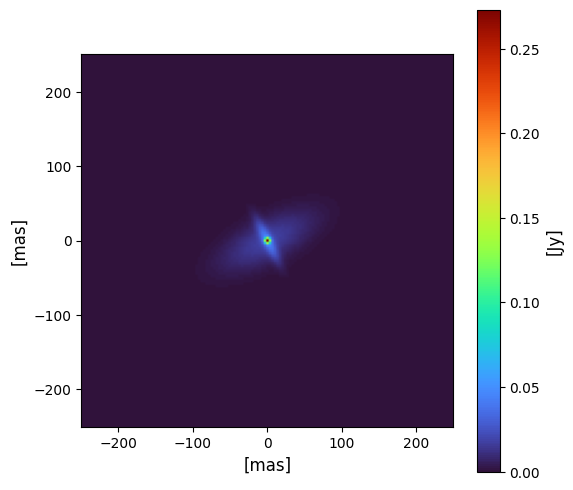

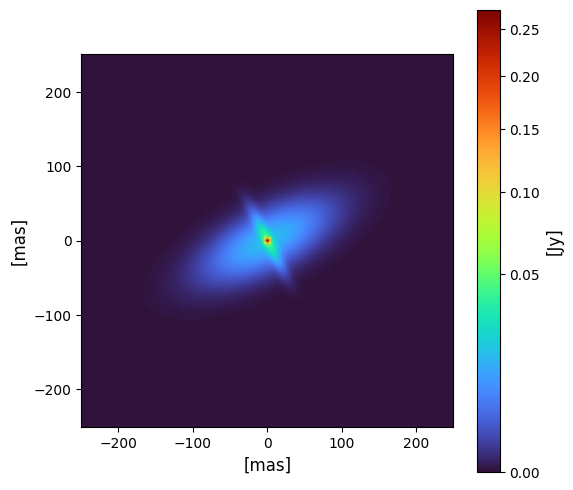

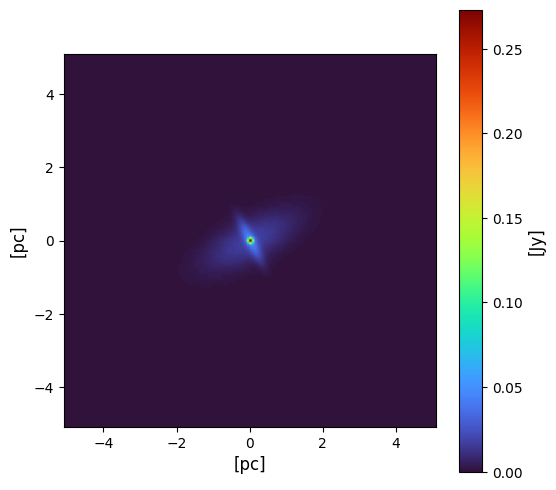

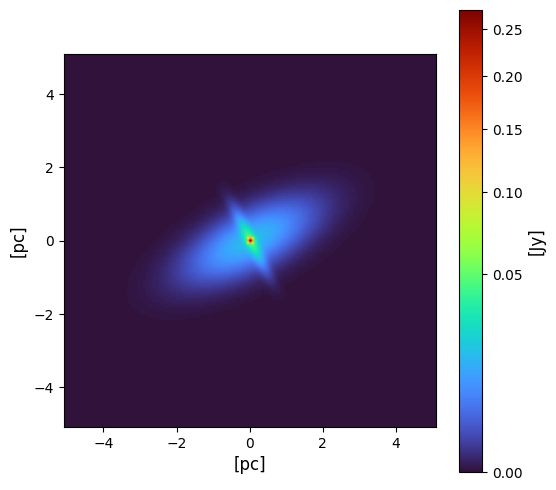

In [18]:
# Generation of the 2D circular Gaussian of Circinus

FWHM_unres = mas_to_pc(pxl_unres_x*CDELT_circinus_original, D_circinus)
FWHM_disk_x = mas_to_pc(pxl_disk_x*CDELT_circinus_original, D_circinus)
FWHM_disk_y = mas_to_pc(pxl_disk_y*CDELT_circinus_original, D_circinus)
FWHM_polar_x = mas_to_pc(pxl_polar_x*CDELT_circinus_original, D_circinus)
FWHM_polar_y = mas_to_pc(pxl_polar_y*CDELT_circinus_original, D_circinus)

FWHM_unres , FWHM_disk_x, FWHM_disk_y , FWHM_polar_x , FWHM_polar_y 



Circinus_1pt_2elliptical = create_model_3compo(FWHM_unres=FWHM_unres, flux_unres=flux_unres,
                                              FWHM_polar_x=FWHM_polar_y, FWHM_polar_y=FWHM_polar_x, flux_polar=flux_polar, theta_polar=theta_polar,
                                              FWHM_disk_x=FWHM_disk_y, FWHM_disk_y=FWHM_disk_x, flux_disk=flux_disk, theta_disk=theta_disk,
                                              pixel_size_mas=METIS_N_band_pixel_scale/2, Dist_source=D_circinus, d_offset=0,
                                              mode='img_n', object_name="Circinus_1pt_2elliptical", 
                                              creating_plot_and_FITS=True, window_lim=250*u.mas)



### 1.4. Real Circinus FITS file
We need to rescale it because the total flux of the image is normalized.

In [19]:
real_data, real_header = fits.getdata(file_real_circinus_N_band_untouched, header=True)
real_data = real_data * Total_flux_circinus/np.sum(real_data)
new_header = real_header.copy()
CDELT = (real_header['CDELT1']*2*u.mas).to(u.degree)

new_header['BUNIT'] = "Jy"
new_header['CDELT1'] = CDELT.value
new_header['CDELT2'] = CDELT.value
new_header['CUNIT1'] = "deg"
new_header['CUNIT2'] = "deg"
new_header['CRPIX1'] = int(real_header['NAXIS1']/2)
new_header['CRPIX2'] = int(real_header['NAXIS2']/2)
fits.writeto(file_real_circinus_N_band, real_data, new_header, overwrite=True)


In [20]:
print(np.sum(real_data))

10.169999321444433 Jy


## 2. Conversion Jy to ADU

### Pt source

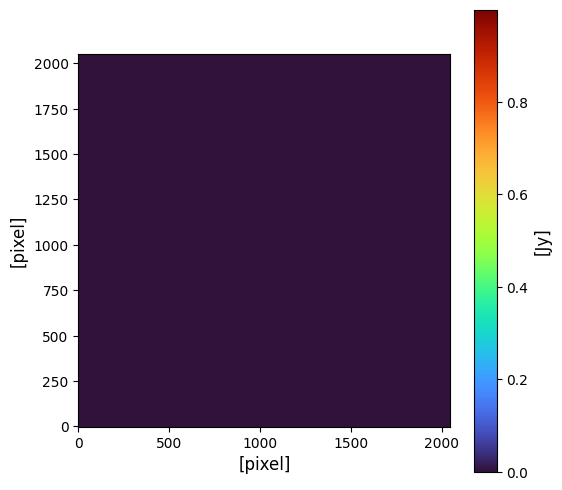

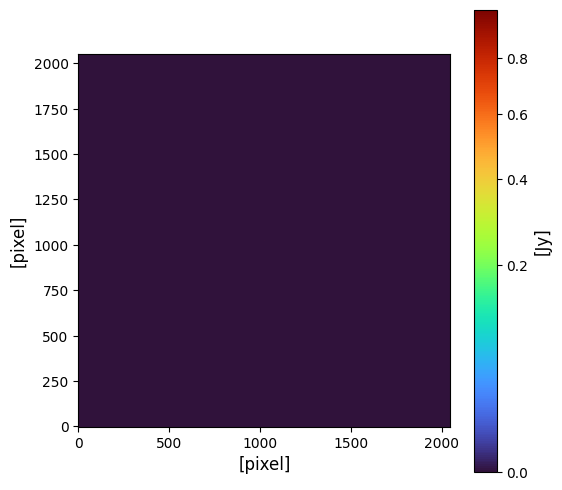

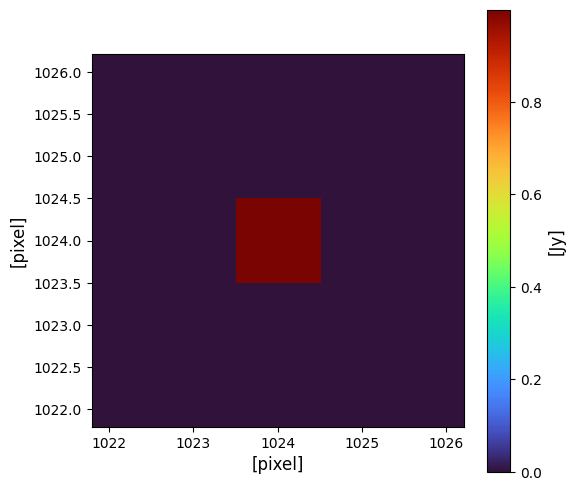

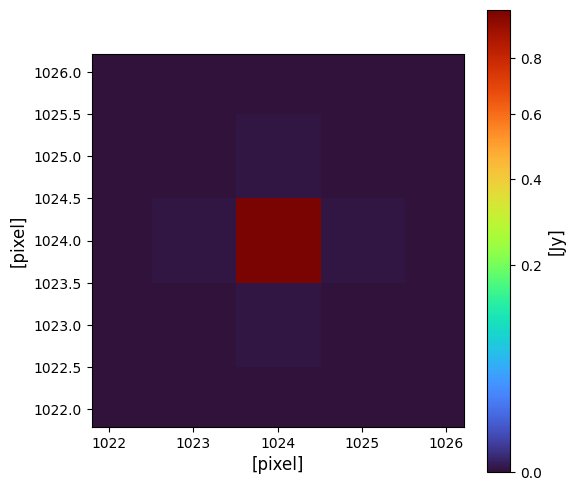

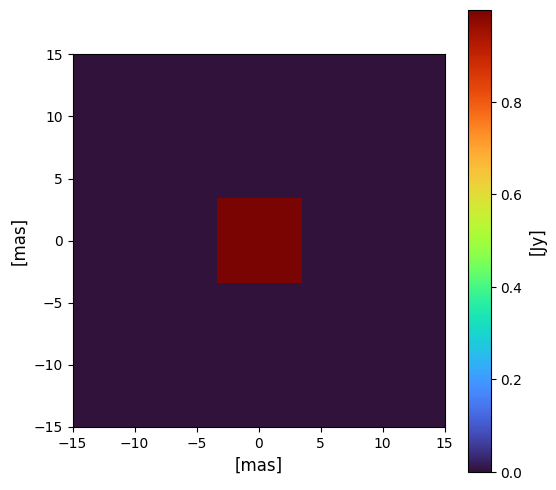

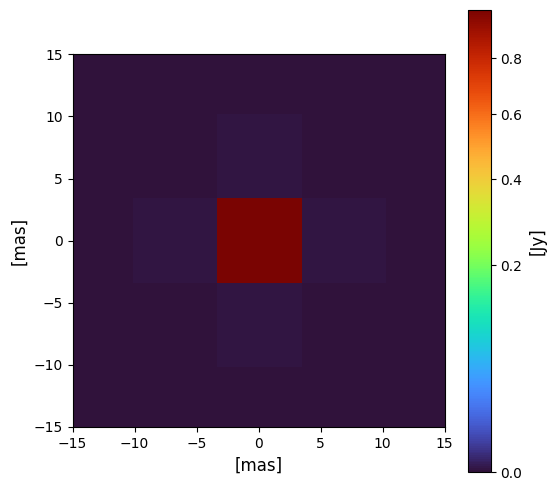

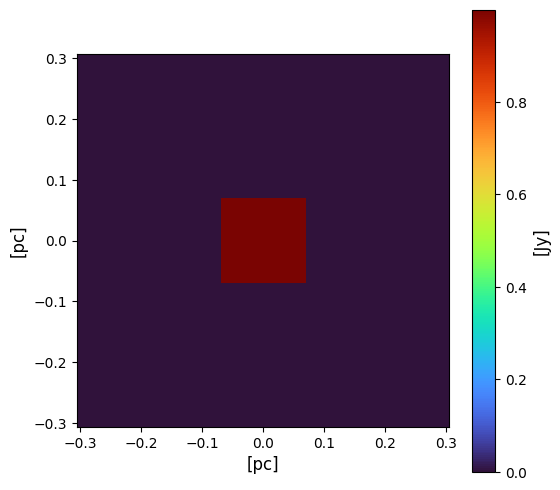

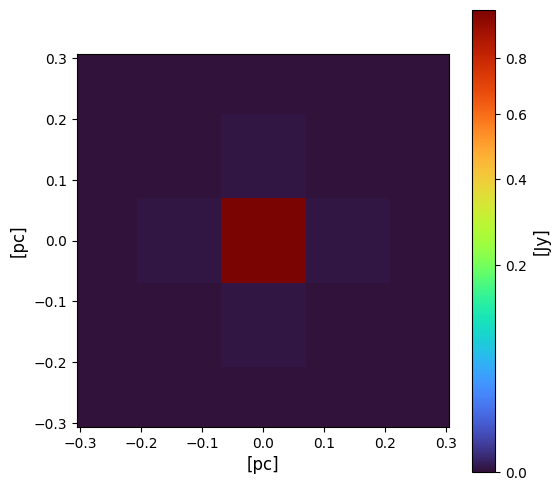

In [21]:
FWHM_unres_ADU_Jy = mas_to_pc(METIS_N_band_pixel_scale/2, D_circinus)

flux_pt = 1*u.Jy

pt_source_1 = Circular_Gaussian_profile(FWHM=FWHM_unres_ADU_Jy, flux=flux_pt, 
                                      pixel_size_mas=METIS_N_band_pixel_scale, Dist_source=D_circinus,
                                      mode='img_n', object_name='unres_pt_source_'+str(flux_pt.value)+'Jy', 
                                      creating_plot_and_FITS=True, window_lim=15*u.mas)

### Uniform source

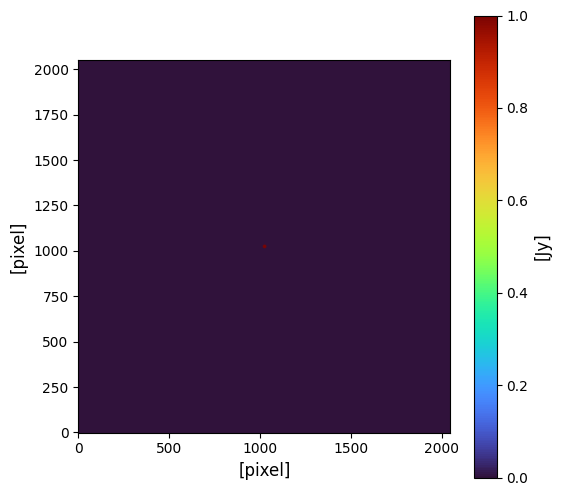

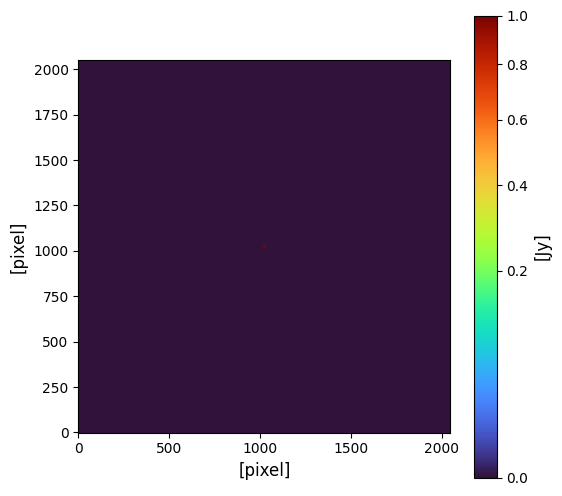

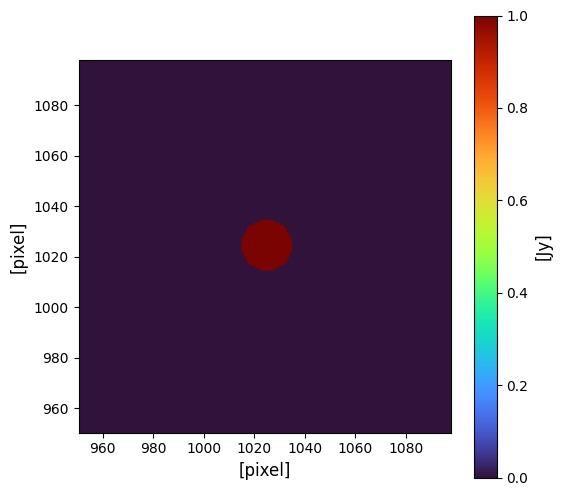

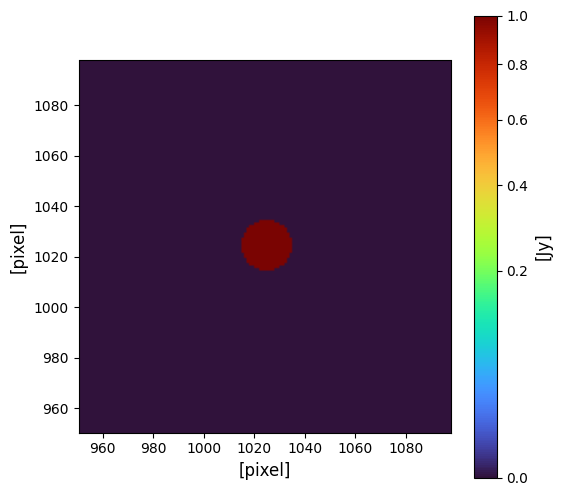

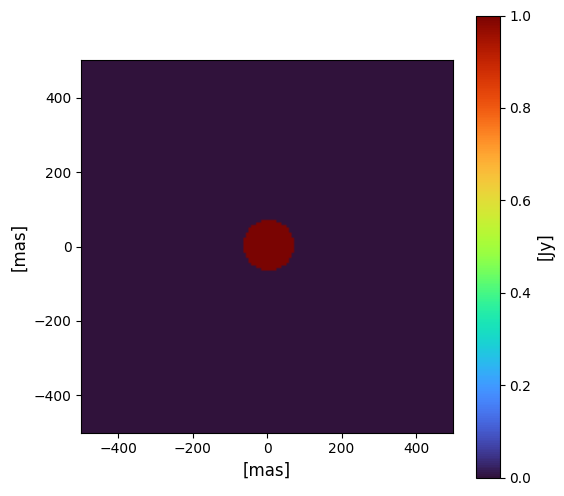

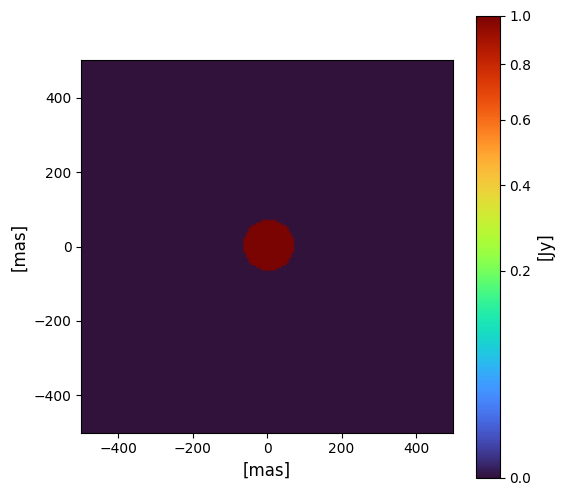

In [22]:
flux_per_pixel = 1*u.Jy
uniform_disk_1 = Uniform_disk_profile(flux_per_pixel=flux_per_pixel, radius=10, pixel_size_mas=METIS_N_band_pixel_scale, 
                                      mode='img_n', object_name='uniform_source'+str(flux_per_pixel.value)+'Jy', 
                                      creating_plot_and_FITS=True, window_lim=500*u.mas)

In [23]:
print('Total flux', np.sum(uniform_disk_1))

Total flux 316.0


## 3. Size variation

In [24]:
FWHM_unres = mas_to_pc(pxl_unres_x*CDELT_circinus_original, D_circinus)
FWHM_disk_x = mas_to_pc(pxl_disk_x*CDELT_circinus_original, D_circinus)
FWHM_disk_y = mas_to_pc(pxl_disk_y*CDELT_circinus_original, D_circinus)
FWHM_polar_x = mas_to_pc(pxl_polar_x*CDELT_circinus_original, D_circinus)
FWHM_polar_y = mas_to_pc(pxl_polar_y*CDELT_circinus_original, D_circinus)

denom = pxl_polar_x*CDELT_circinus_original
print(denom)
size_ratio_30mas = (30*u.mas).to(u.mas)/denom
size_ratio_1as = (1*u.arcsecond).to(u.mas)/denom

105.46875 mas


### "Circinus" 30 mas

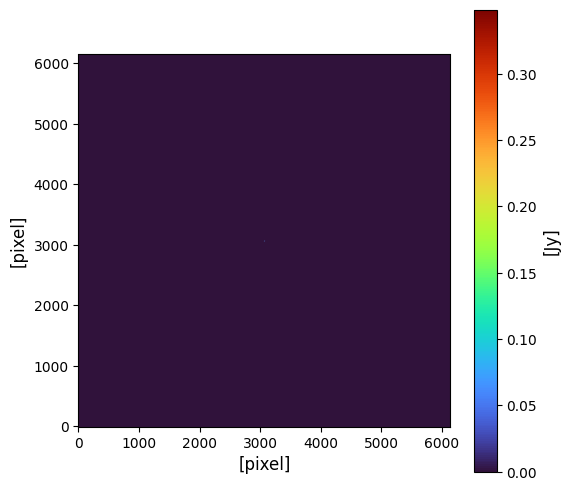

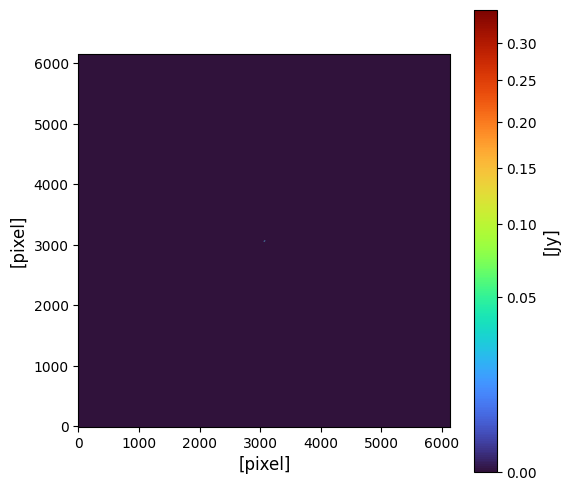

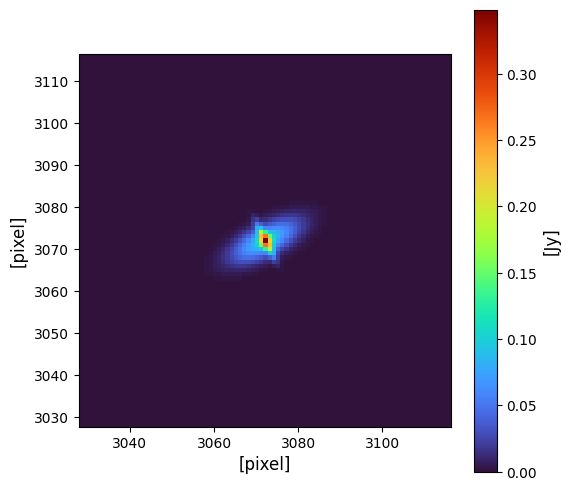

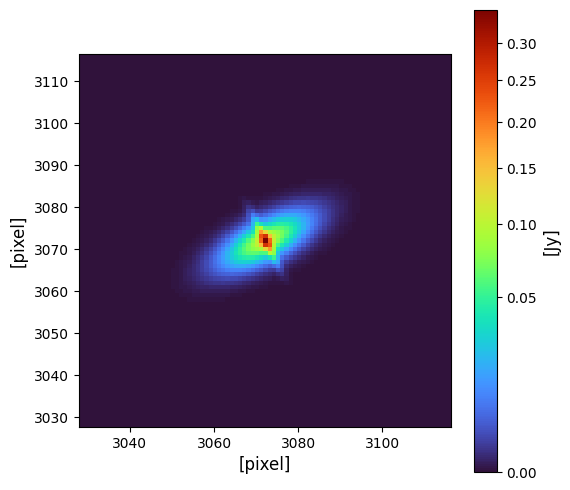

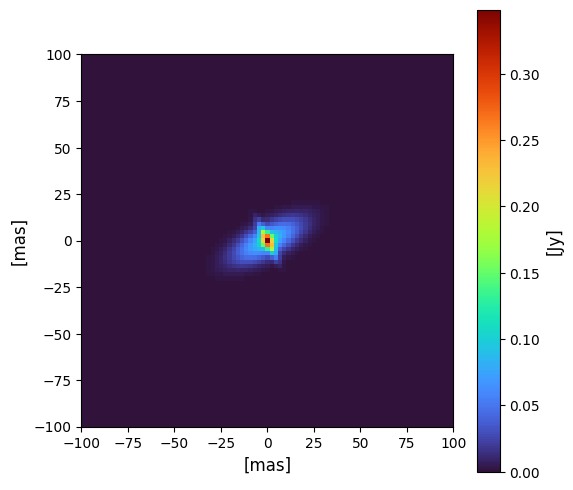

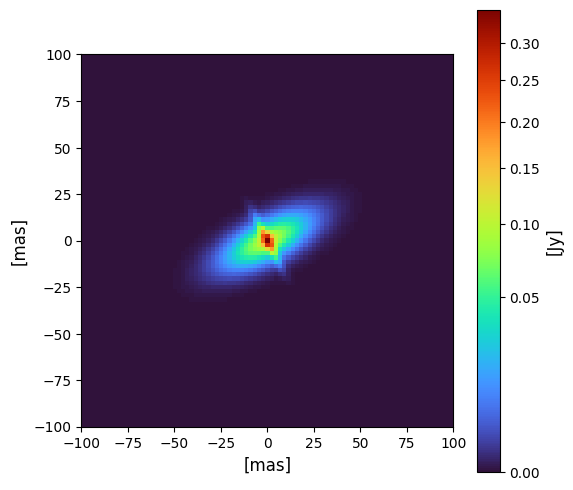

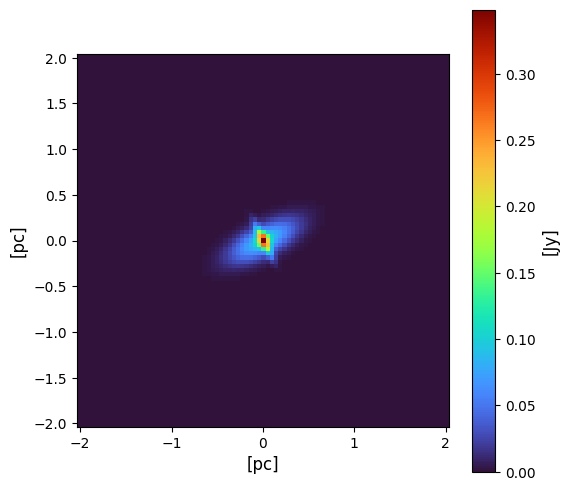

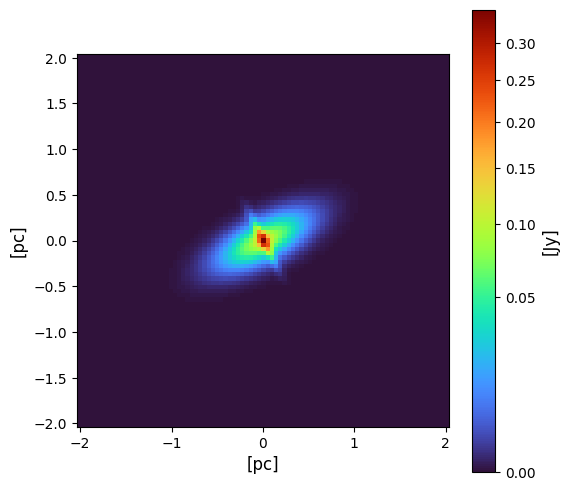

In [25]:
Circinus_30mas = create_model_3compo(FWHM_unres=FWHM_unres, flux_unres=flux_unres,
                                              FWHM_polar_x=FWHM_polar_y*size_ratio_30mas, FWHM_polar_y=FWHM_polar_x*size_ratio_30mas, flux_polar=flux_polar, theta_polar=theta_polar,
                                              FWHM_disk_x=FWHM_disk_y*size_ratio_30mas, FWHM_disk_y=FWHM_disk_x*size_ratio_30mas, flux_disk=flux_disk, theta_disk=theta_disk,
                                              pixel_size_mas=METIS_N_band_pixel_scale/3, Dist_source=D_circinus, d_offset=0,
                                              mode='img_n', object_name="Circinus_30mas", 
                                              creating_plot_and_FITS=True, window_lim=100*u.mas)

### "Circinus" 1 as

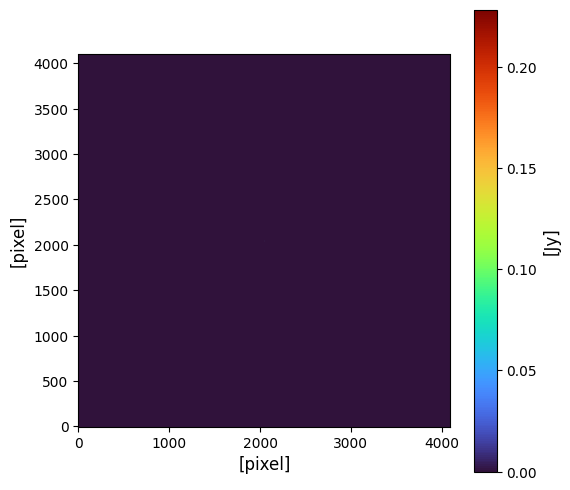

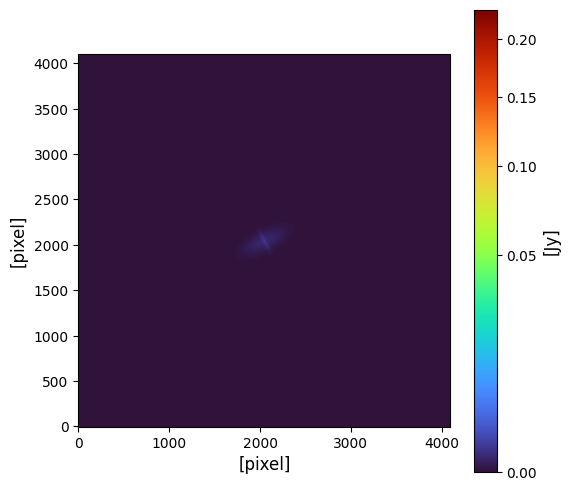

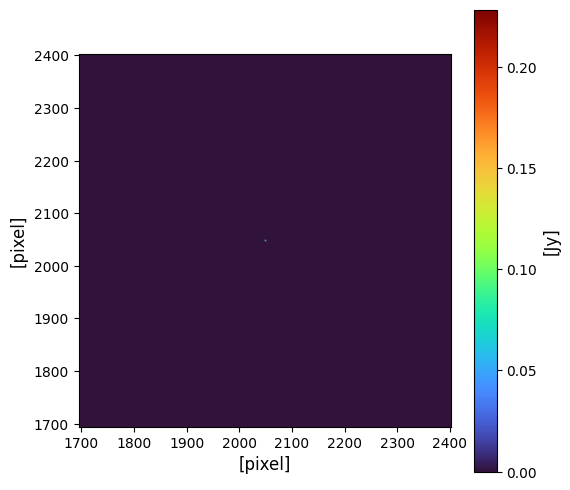

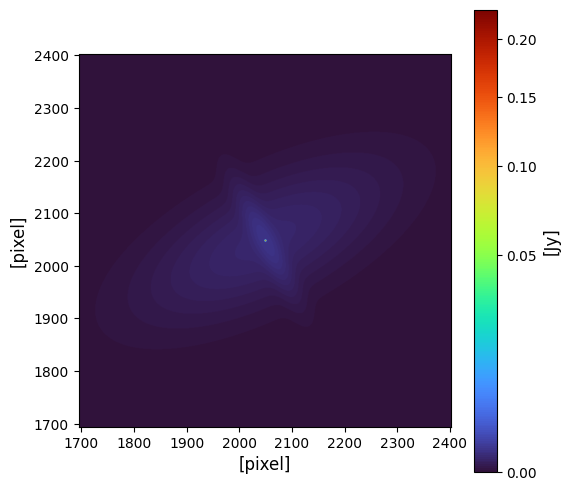

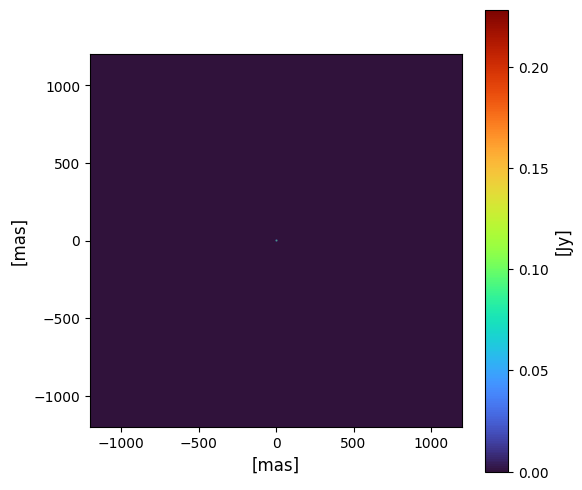

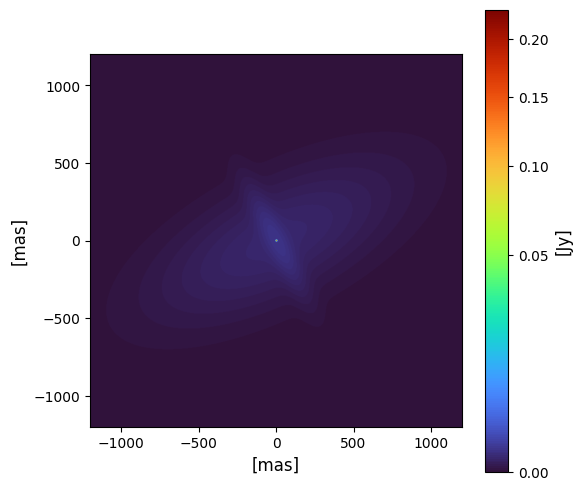

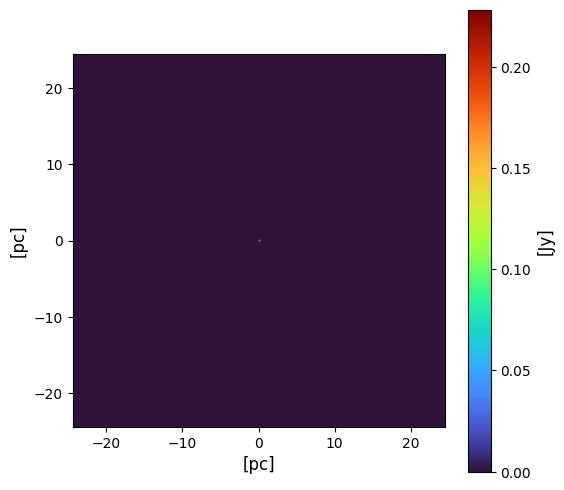

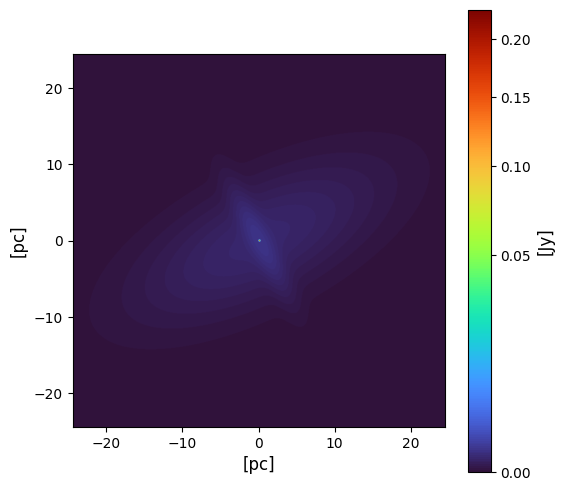

In [26]:
Circinus_1as = create_model_3compo(FWHM_unres=FWHM_unres, flux_unres=flux_unres,
                                              FWHM_polar_x=FWHM_polar_y*size_ratio_1as, FWHM_polar_y=FWHM_polar_x*size_ratio_1as, flux_polar=flux_polar, theta_polar=theta_polar,
                                              FWHM_disk_x=FWHM_disk_y*size_ratio_1as, FWHM_disk_y=FWHM_disk_x*size_ratio_1as, flux_disk=flux_disk, theta_disk=theta_disk,
                                              pixel_size_mas=METIS_N_band_pixel_scale/2, Dist_source=D_circinus, d_offset=0,
                                              mode='img_n', object_name="Circinus_1as", 
                                              creating_plot_and_FITS=True, window_lim=1200*u.mas)

## 4. Flux ratio variation

In [27]:
FWHM_unres = mas_to_pc(pxl_unres_x*CDELT_circinus_original, D_circinus)
FWHM_disk_x = mas_to_pc(pxl_disk_x*CDELT_circinus_original, D_circinus)
FWHM_disk_y = mas_to_pc(pxl_disk_y*CDELT_circinus_original, D_circinus)
FWHM_polar_x = mas_to_pc(pxl_polar_x*CDELT_circinus_original, D_circinus)
FWHM_polar_y = mas_to_pc(pxl_polar_y*CDELT_circinus_original, D_circinus)

### Flux ratio = 1/20

Flux unres = 0.5085 Jy
Flux disk = 1.654788829787234 Jy
Flux polar = 8.006711170212766 Jy


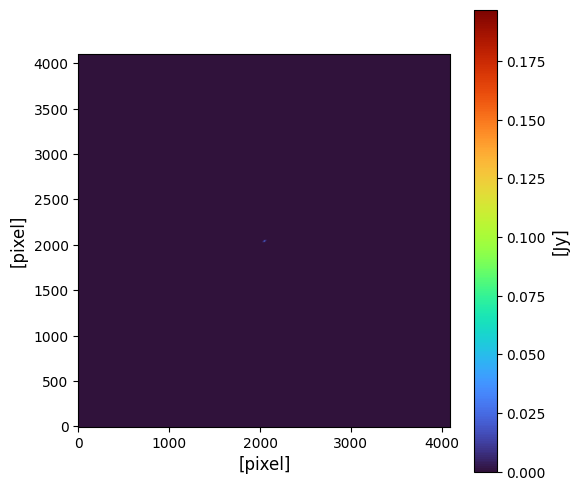

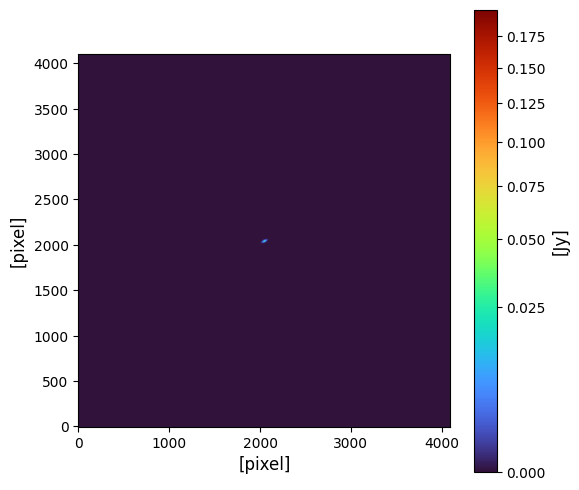

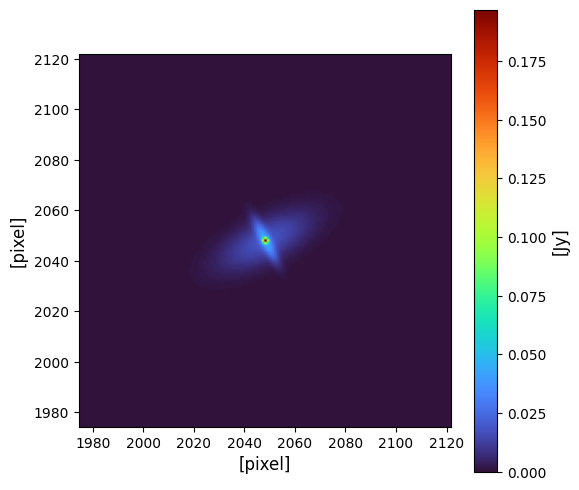

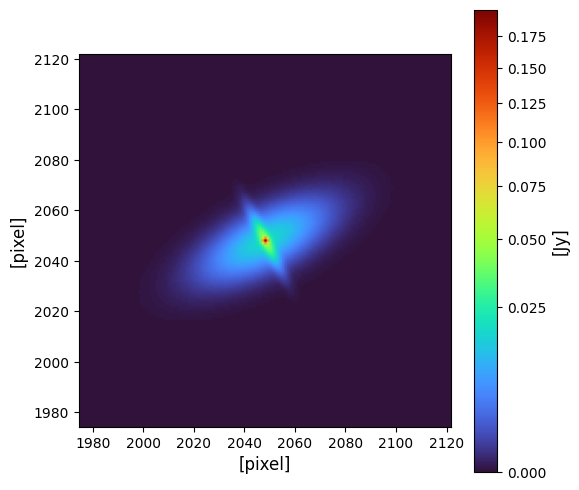

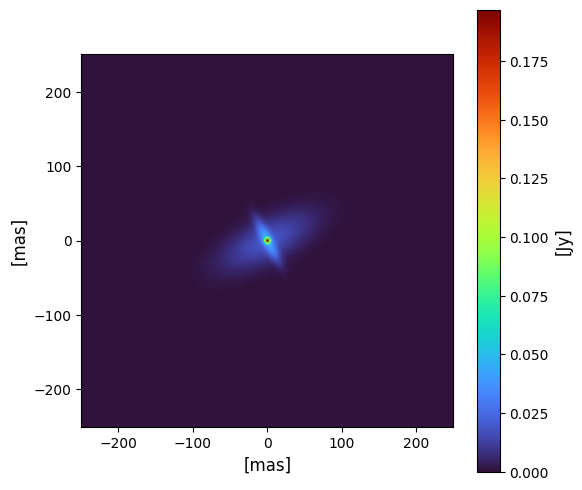

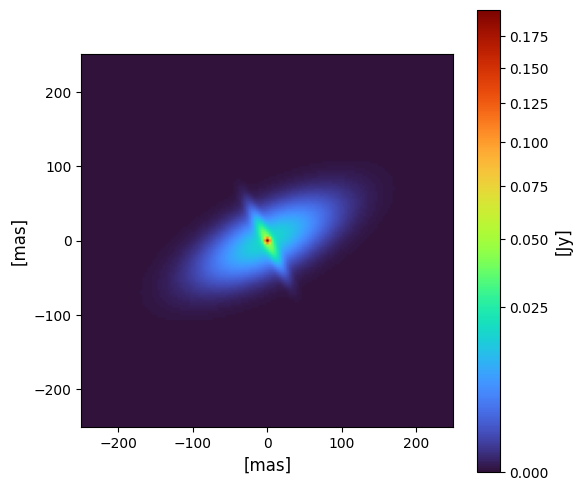

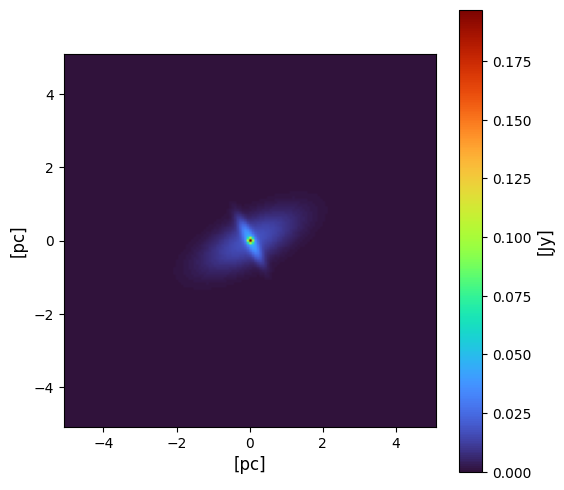

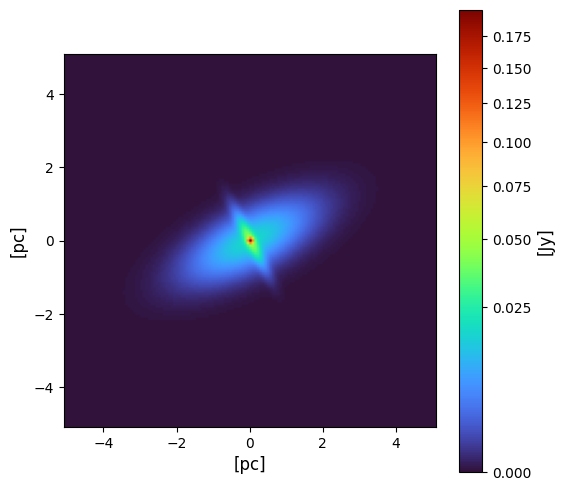

In [28]:
flux_unres_1_20 = Total_flux_circinus/20
flux_extended_1_20 = Total_flux_circinus-flux_unres_1_20
flux_disk_1_20 = flux_extended_1_20*frac_flux_disk_circinus
flux_polar_1_20 = flux_extended_1_20*frac_flux_polar_circinus
print('Flux unres =', flux_unres_1_20)
print('Flux disk =', flux_disk_1_20)
print('Flux polar =', flux_polar_1_20)

Circinus_1_20_flux = create_model_3compo(FWHM_unres=FWHM_unres, flux_unres=flux_unres_1_20,
                                              FWHM_polar_x=FWHM_polar_y, FWHM_polar_y=FWHM_polar_x, flux_polar=flux_polar_1_20, theta_polar=theta_polar,
                                              FWHM_disk_x=FWHM_disk_y, FWHM_disk_y=FWHM_disk_x, flux_disk=flux_disk_1_20, theta_disk=theta_disk,
                                              pixel_size_mas=METIS_N_band_pixel_scale/2, Dist_source=D_circinus, d_offset=0,
                                              mode='img_n', object_name="Circinus_1_20_flux", 
                                              creating_plot_and_FITS=True, window_lim=250*u.mas)

### Flux ratio = 1/2

Flux unres = 5.085 Jy
Flux disk = 0.8709414893617021 Jy
Flux polar = 4.2140585106382975 Jy


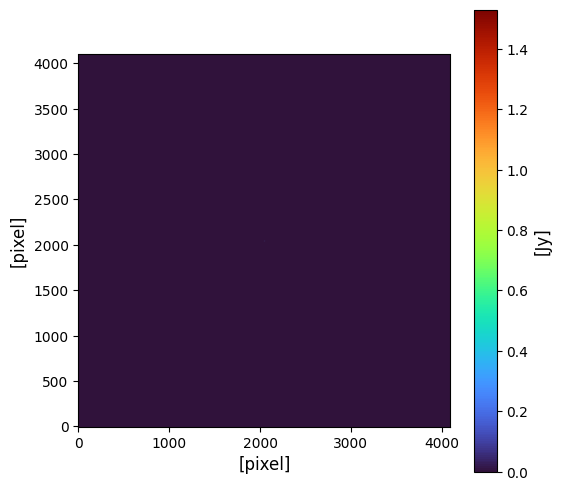

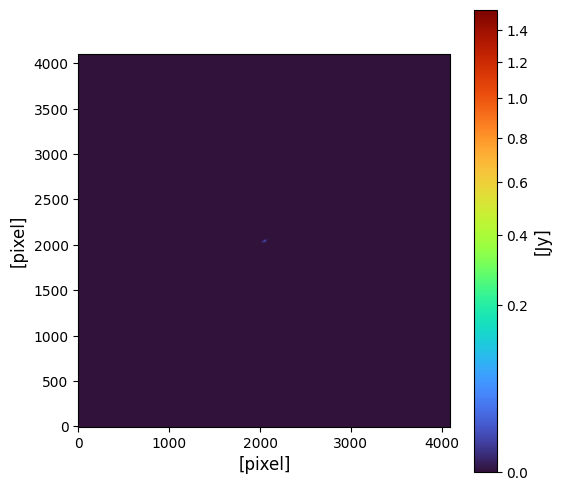

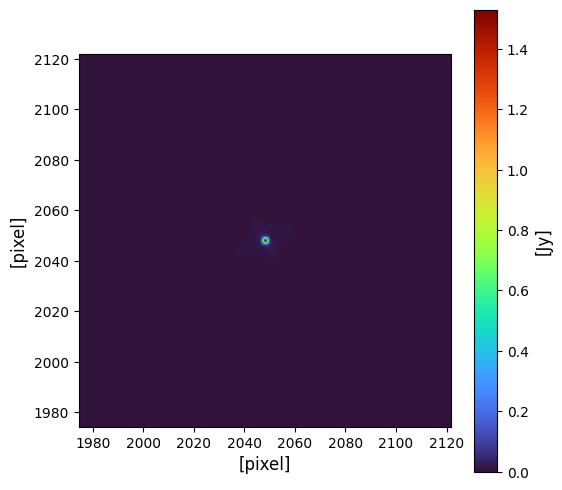

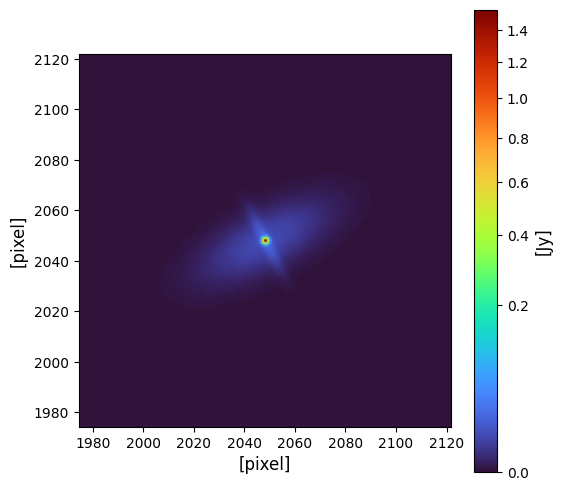

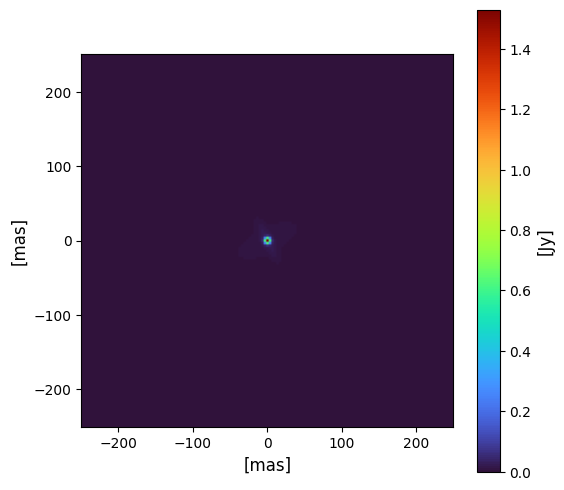

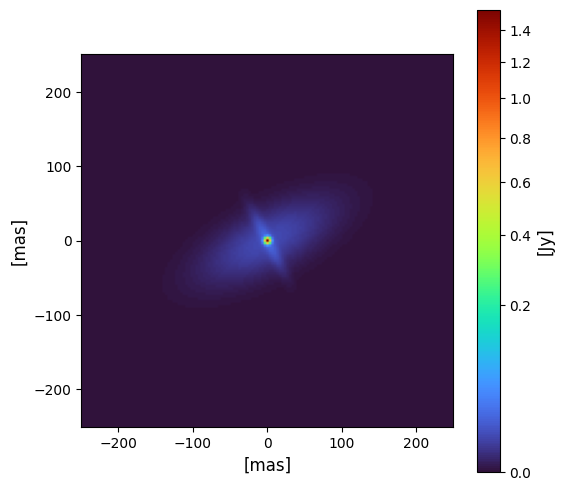

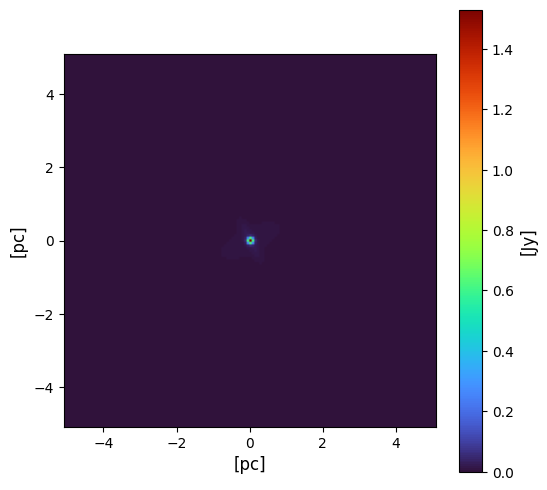

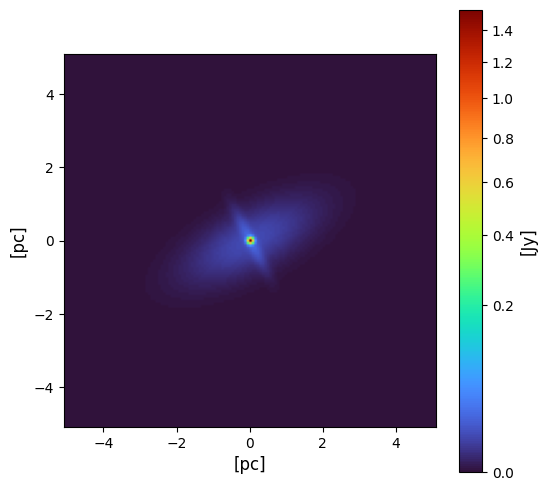

In [29]:
flux_unres_1_2 = Total_flux_circinus/2
flux_extended_1_2 = Total_flux_circinus-flux_unres_1_2
flux_disk_1_2 = flux_extended_1_2*frac_flux_disk_circinus
flux_polar_1_2 = flux_extended_1_2*frac_flux_polar_circinus
print('Flux unres =', flux_unres_1_2)
print('Flux disk =', flux_disk_1_2)
print('Flux polar =', flux_polar_1_2)

Circinus_1_20_flux = create_model_3compo(FWHM_unres=FWHM_unres, flux_unres=flux_unres_1_2,
                                              FWHM_polar_x=FWHM_polar_y, FWHM_polar_y=FWHM_polar_x, flux_polar=flux_polar_1_2, theta_polar=theta_polar,
                                              FWHM_disk_x=FWHM_disk_y, FWHM_disk_y=FWHM_disk_x, flux_disk=flux_disk_1_2, theta_disk=theta_disk,
                                              pixel_size_mas=METIS_N_band_pixel_scale/2, Dist_source=D_circinus, d_offset=0,
                                              mode='img_n', object_name="Circinus_1_2_flux", 
                                              creating_plot_and_FITS=True, window_lim=250*u.mas)

## 5. PSFs

### Pt source = 0.77 Jy

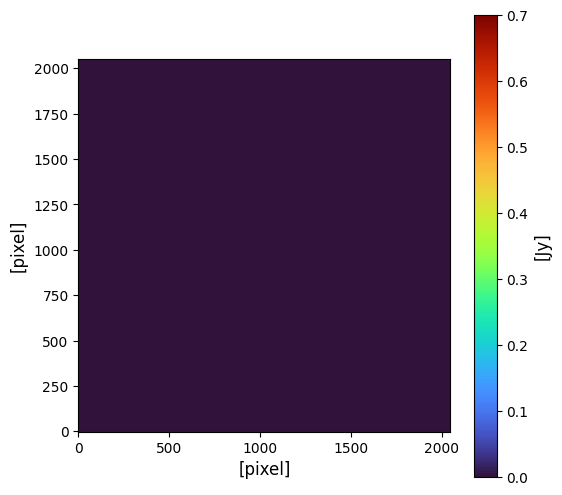

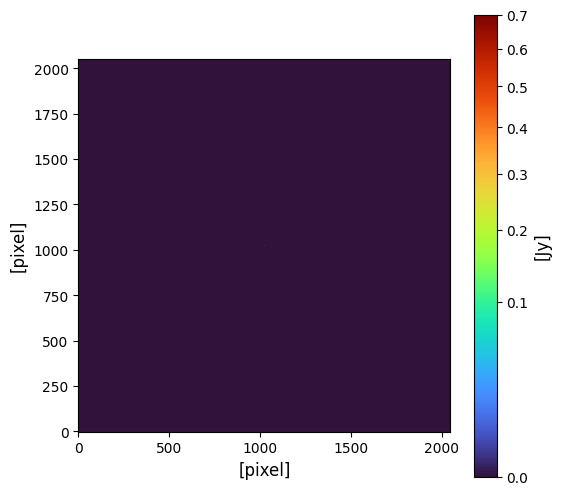

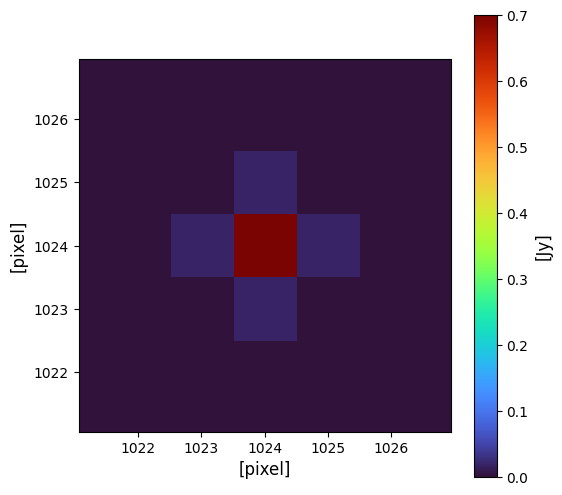

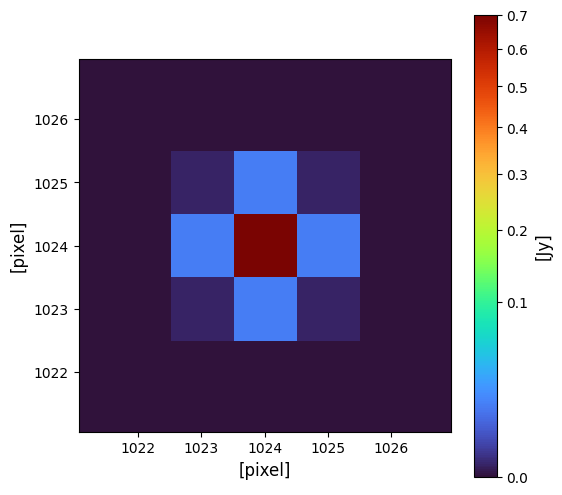

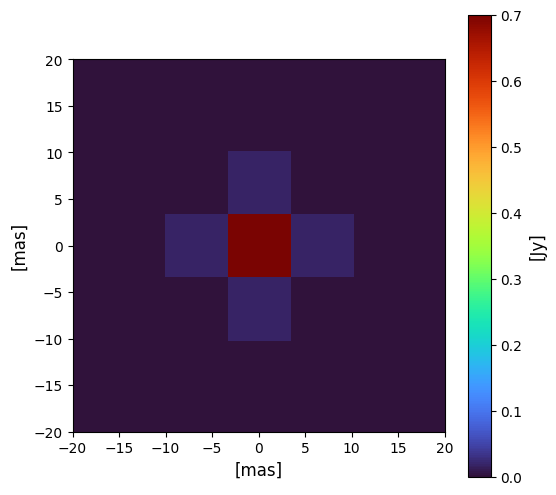

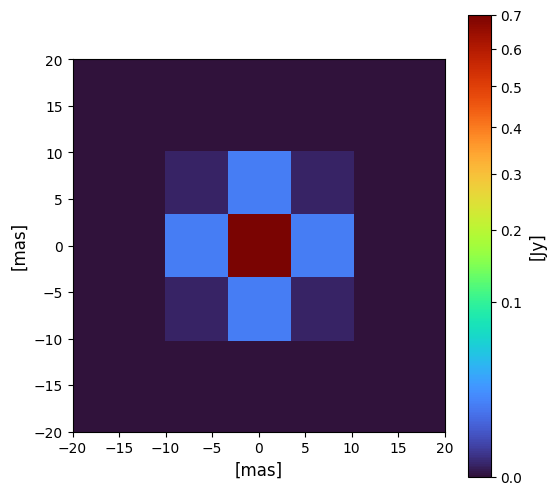

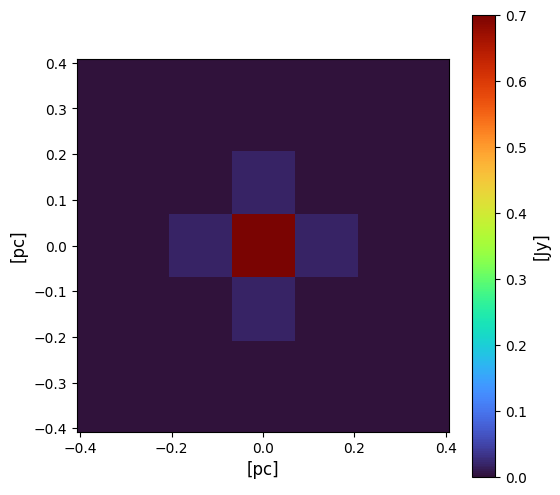

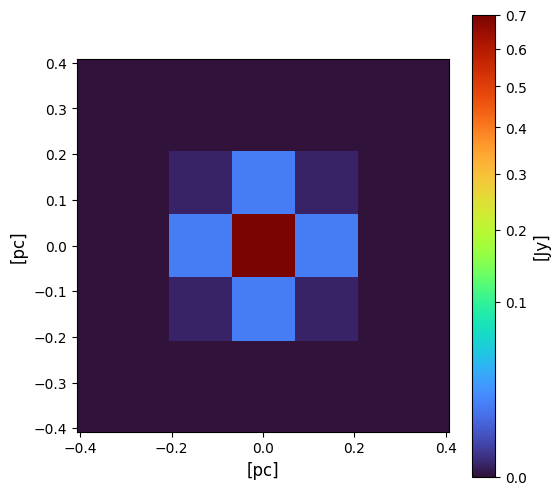

In [30]:
FWHM_unres = mas_to_pc(pxl_unres_x*CDELT_circinus_original, D_circinus)

flux_pt = 0.77*u.Jy

pt_source_077 = Circular_Gaussian_profile(FWHM=FWHM_unres, flux=flux_pt, 
                                      pixel_size_mas=METIS_N_band_pixel_scale, Dist_source=D_circinus,
                                      mode='img_n', object_name='unres_pt_source_'+str(flux_pt.value)+'Jy', 
                                      creating_plot_and_FITS=True, window_lim=20*u.mas)

### Pt source = 1/20

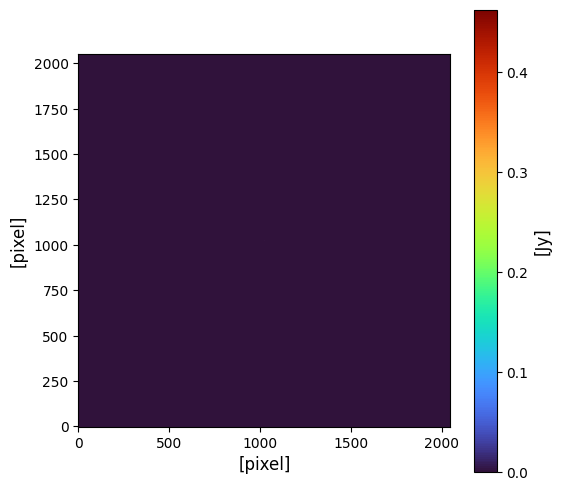

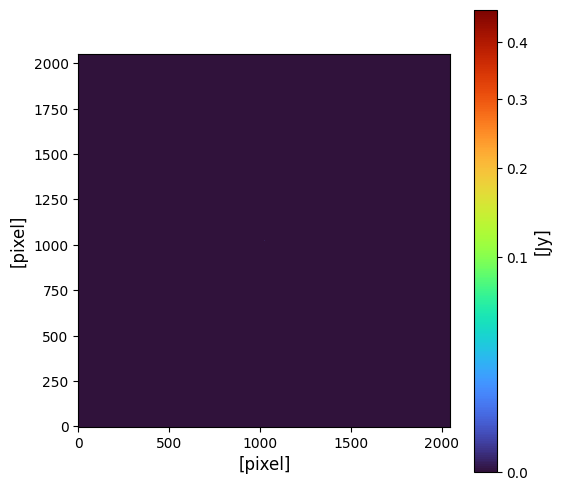

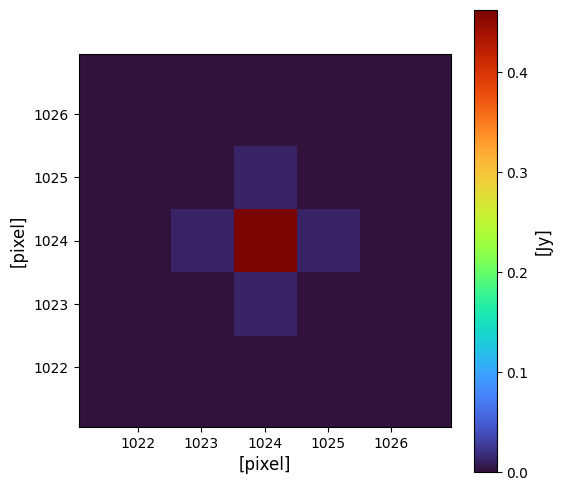

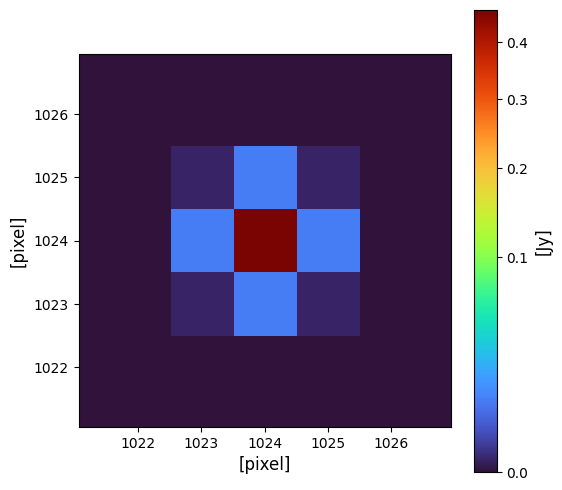

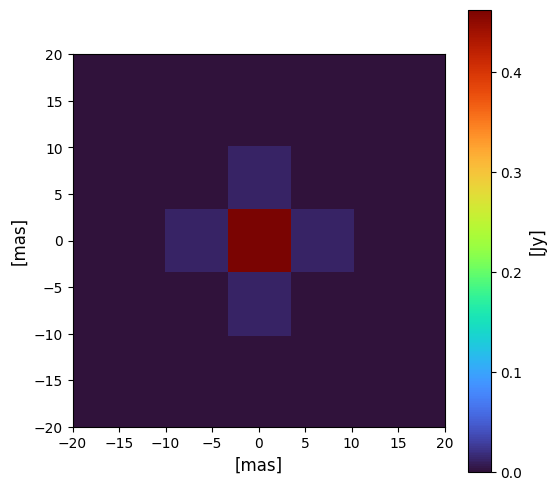

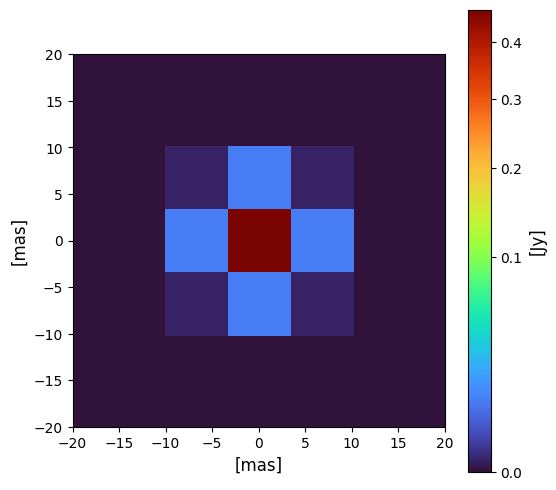

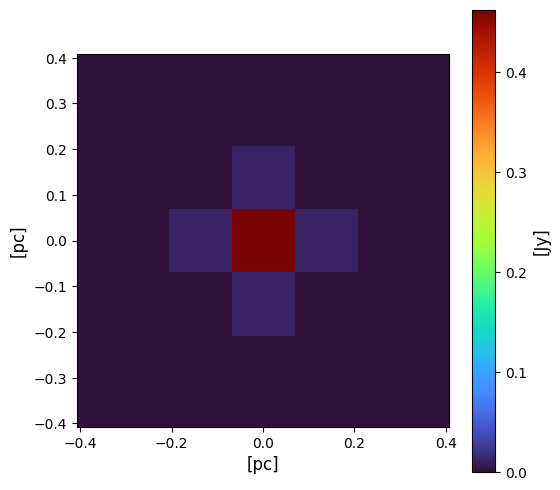

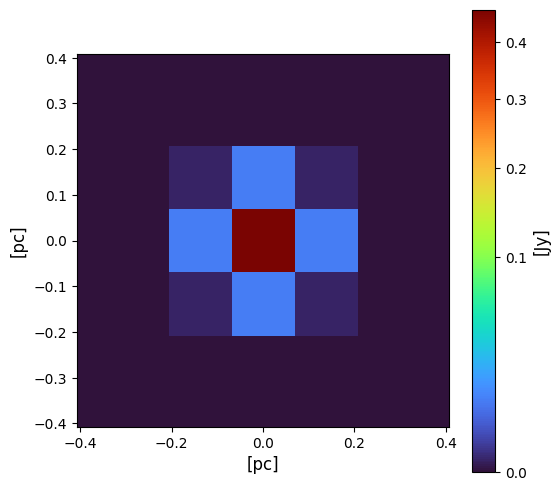

In [31]:
flux_pt = Total_flux_circinus/20
FWHM_unres = mas_to_pc(pxl_unres_x*CDELT_circinus_original, D_circinus)

pt_source_1_20 = Circular_Gaussian_profile(FWHM=FWHM_unres, flux=flux_pt, 
                                      pixel_size_mas=METIS_N_band_pixel_scale, Dist_source=D_circinus,
                                      mode='img_n', object_name='unres_pt_source_'+str(flux_pt.value)+'Jy', 
                                      creating_plot_and_FITS=True, window_lim=20*u.mas)

### Pt source = 1/2

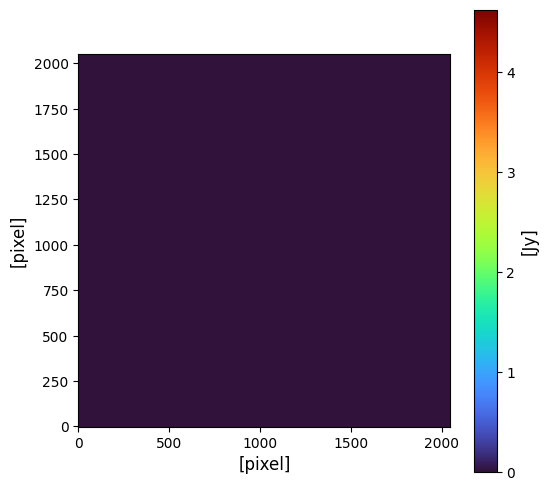

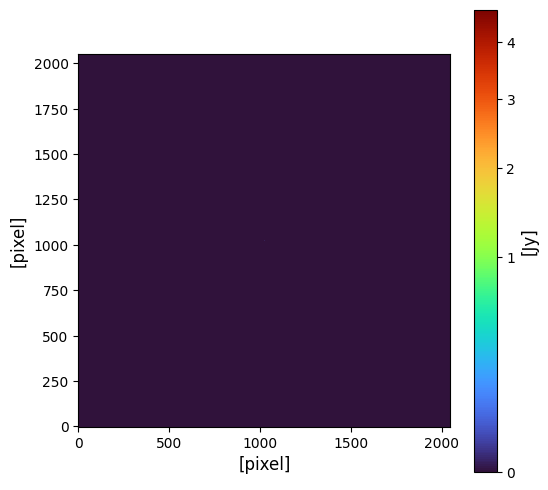

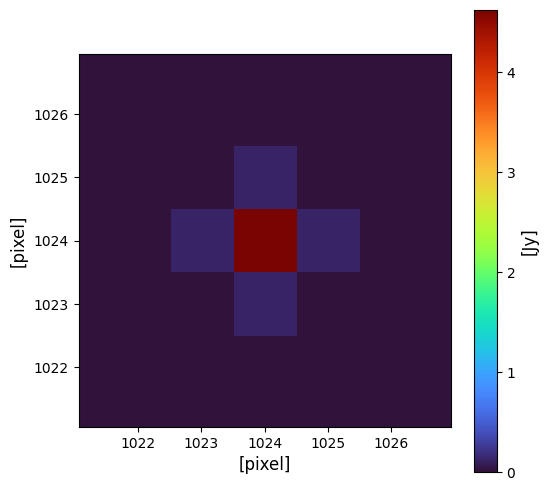

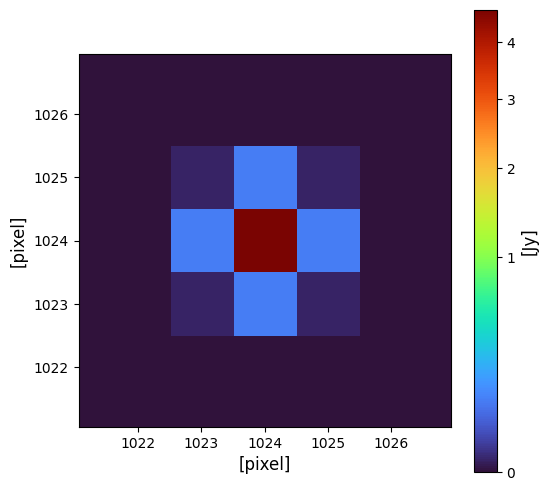

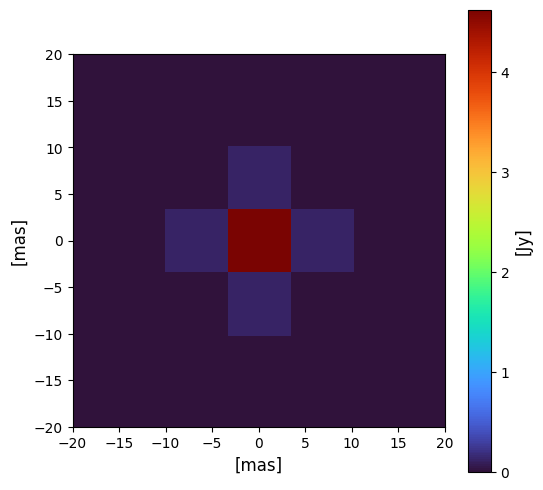

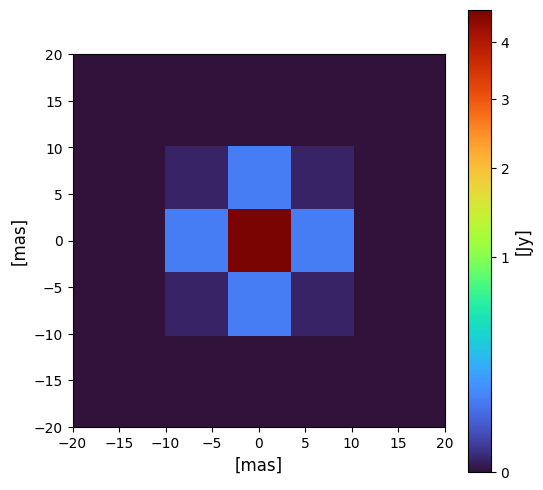

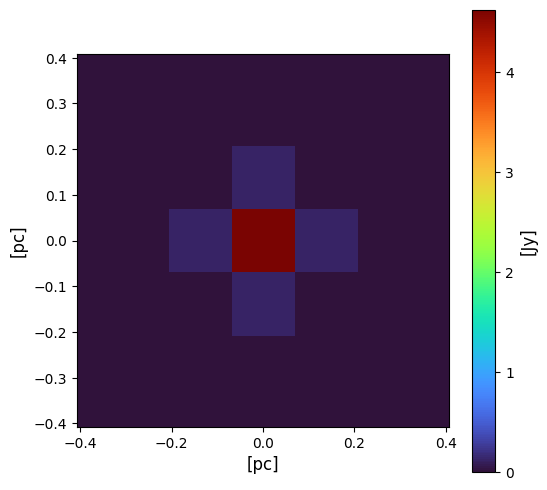

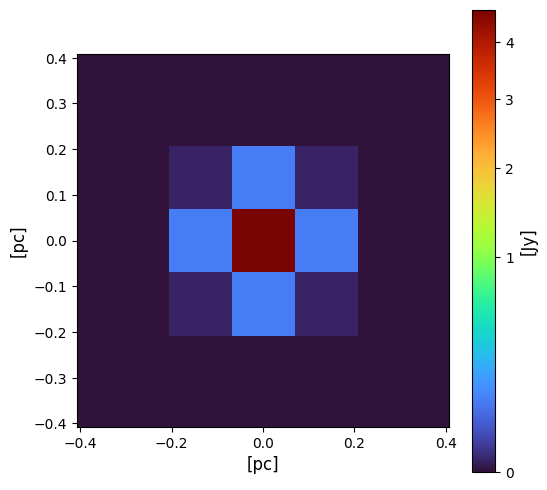

In [32]:
flux_pt = Total_flux_circinus/2
FWHM_unres = mas_to_pc(pxl_unres_x*CDELT_circinus_original, D_circinus)

pt_source_1_2 = Circular_Gaussian_profile(FWHM=FWHM_unres, flux=flux_pt, 
                                      pixel_size_mas=METIS_N_band_pixel_scale, Dist_source=D_circinus,
                                      mode='img_n', object_name='unres_pt_source_'+str(flux_pt.value)+'Jy', 
                                      creating_plot_and_FITS=True, window_lim=20*u.mas)

## Sources

[*"The subarcsecond mid-infrared view of local active galactic nuclei: I. The N- and Q-band imaging atlas"* by D. Asmus et al.](https://arxiv.org/abs/1310.2770)